# Multi-Bank Liquidity — Diagnosis, Fix, and Rebalancing Policy

Rebuilding the squad's notebook to answer the real question: **when, how much, and from where should money move across 6 accounts in 3 currencies, to minimize shortfall risk without moving money unnecessarily?**

**How to read this notebook.** All logic lives in [`src/`](../src/) (ingestion, quality, forecast, policies, MILP, backtest), covered by 28 `pytest` tests. This notebook only imports and displays results. Every number is generated from data: change an assumption in [`src/config.py`](../src/config.py), rerun, and all tables and numbers update.

| Part | What it answers |
|---|---|
| **0** | Declared assumptions (everything *not* observable in the data) |
| **1** | What's wrong with the squad's approach, with evidence (D1–D10), and the fixed pipeline |
| **2** | Proposed approach: probabilistic forecast → quantile policy → MILP → backtest with a cost-risk frontier |
| **3** | Two explanations: for the data scientist and for Treasury |
| **4 / 5** | Ways of working (AI use) and productionization |

> **Run time:** ~5–6 min (the backtest solves one MILP per day and per policy).


## Table of Contents

  - 0 · Declared assumptions
- Part 1 · Diagnosing and fixing the squad's approach
  - 1.1 Starting point: the squad's notebook, reproduced
  - 1.2 The data: what's broken and how it's fixed
    - D1 · Silent `dropna` after `coerce`: the squad loses 17.6% of the history
    - The fixed pipeline (`src/ingest.py`) and its quality report
    - D2 · Duplicates and sign/scale errors never caught → the squad's forecast is contaminated for 14 days
    - D3 · 9 currency labels treated as different currencies
    - D4 · The forecast is a 14-day moving average of the **level**: no drift, no seasonality, no horizon
    - D4b · Weekly seasonality: identify it before modeling it
      - D4b-1 · Look at the seasonality before testing it
      - D4b-2 · ACF / PACF: do we need to difference? where is the seasonality?
    - D4c · Validation with `TimeSeriesSplit` and an ETS forecast
    - D4d · XGBoost with lags: over-, under-, or well-balanced (±15%)?
    - D4e · The challenge: one model per account (not one global model), tuned — does it improve MAPE?
    - D4f · Forecast for the dataset's last 14 days, all models side by side
    - D5 · No uncertainty
    - D6 · Donor = `idxmax()` of the **nominal** balance, no currency conversion
    - D7 · Invented fixed thresholds, covering only 4 of 6 accounts
    - D8 and D9 · `transfer_today: True` ignores lag; fees are ignored
    - D10 · Circular validation: before/after average around May 1, summing COP+USD+MXN
    - D11 · Which model best predicts the last 14 REAL days? (`ets_flujos` wins on MAPE/sMAPE)
    - D12 · Why D11's winner doesn't win the rebalancing engine (point vs. distribution) — the engine is rerun with `ets` and cost is compared
  - 2.8 Rebalancing engine: when, how much, and from where (trigger + sizing, formalized) — **shown here, right after D12, not further below**
    - Real case: 2025-05-06
- Part 2 · A sound approach to the real question (2.0–2.7, 2.9–2.10; 2.8 already covered above)
  - 2.0 Formulation (what "shortfall" means and how it's decided) — **pending in this draft**
  - 2.1 Reconciliation: does the transfer log explain anything about the balances? — **pending**
  - 2.2 Flow structure — **pending**
  - 2.3 Probabilistic forecast: model ladder with walk-forward backtest
  - 2.4–2.7 (summary) · Operating floor, quantile and MILP policies, backtest, fee vs. penalty
  - 2.9 Sensitivity — figures from a reference run, still to be reproduced inside this notebook
  - 2.10 Where it can still fail
- Part 3 · Two explanations of the same result — **pending**
  - 3.1 For the squad's data scientist
  - 3.2 For Treasury
- Part 4 · Ways of working: where AI was used and where not — **pending**
- Part 5 · From notebook to production (half a page) — **pending**
- Open decisions and verification — **pending**
  (the executive summary says "the last cell verifies this"; that cell doesn't exist yet)


## Executive Summary

*(figures from this notebook's run; the last cell verifies them)*

- **The squad's "it looks like it's working" is false.** Its pipeline loses 17.6% of rows, treats 9 labels as 9 currencies, lets 7 corrupted readings and 6 unexplained episodes through, picks the donor by *nominal* balance with no currency conversion, and "validates" with a before/after average that sums COP+USD+MXN (a −9.6% drop presented as a success).
- **Data fixed with the accounting identity** (`b[t] = b[t-1] + in − out`): a 6 × 270 panel, 0 nulls, 0 negatives, residual ≈ 0.01. Anything unexplained goes to a marked quarantine instead of being guessed at.
- **Probabilistic net-flow forecast.** Every model beats seasonal-naive by ~26–34%, but **none beats an empirical bootstrap** (the net flow's mean carries almost no signal): the value is in the quantiles, with ~93% p5–p95 coverage.
- **Backtest with a counterfactual** (210 days × 6 accounts, floor = 25 days of outflow): doing nothing leaves **33 account-days short**; the squad's rule, **86** (worse than nothing, USD 6.3k, 200 transfers); the quantile policy, **0** (USD 5.0k, 49 transfers); the **MILP, 0** (USD 2.1k, 22 transfers, all same-currency — in fact, within 3 fixed operational–reserve pools, see 2.7). The MILP also *chooses not to move money* when operating costs more than the expected penalty.
- **Sensitivity:** robust to FX ±10% and to a forced lag; **fragile to a biased forecast** (1–3 account-days short reappear); at a 30-day floor the system runs out of liquidity — a funding problem, not a rebalancing one.
- **Pending human decisions:** the floor (K), the official COP FX rate, the fixed cost, the penalty, the 6 unexplained episodes, and what the transfer log actually represents (it **doesn't show up** in the balances). See the end of the notebook.
- **Seasonality and time validation (D4b–D4d, Appendix A).** The weekly pattern lives in inflows/outflows, not in the balance (a random walk with drift, `d = 1`); lagged XGBoost doesn't clearly beat "last balance" (wins 18 of 30 blocks). Redundant with 2.3, kept as an appendix.
- **Simple wait rule (2.7b).** Waiting when the shortfall is only in the tail and there's still slack cuts transfers from 49 to 13 and cost from USD 4,955 to USD 2,555, but leaves 3 account-days short; the MILP reaches 0 shortfalls at USD 2,099. The rule is good for spotting opportunities and explaining the decision, not for replacing the MILP.


In [1]:
import sys
from pathlib import Path

# el notebook vive en notebooks/: se sube hasta encontrar la carpeta src/
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as cfg, ingest, quality, features, diagnosis as D
from src import forecast as F, policy as P, optimize as O, backtest as B, plots

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

## 0 · Declared Assumptions

Everything **not observable in the data** lives here and in [`src/config.py`](../src/config.py); no business constant lives in the modeling code. Items marked **[HUMAN DECISION]** are reasonable defaults **pending Treasury validation**; the backtest stress-tests them (Part 2.8) precisely so the result doesn't blindly depend on them.

**Operating floor (K × 28-day average outflow).** Not given by the case or by `SPEC_caso_liquidez.md` — it's our own assumption, chosen for system-wide solvency: K=25, because at K=30 the system's minimum aggregate surplus drops to ~USD 58k and the problem stops being about rebalancing (details in 2.4, sensitivity in 2.8). It defines "shortfall" for every policy, backtest, and optimization in this notebook. **[HUMAN DECISION] — pending Treasury validation.**

**Deficit penalty (`cfg.DEFICIT_PENALTY_PER_DAY` = 0.2% of the shortfall per account-day, `cfg.PENALTY_WEIGHT` = 1.0 operational / 0.5 reserve).** This is the price this notebook puts on "falling below the floor," used in 2.6/2.7/4.4 to decide whether it's cheaper to transfer (fee + `cfg.FIXED_COST_USD` = USD 25 flat) or absorb the penalty. **It doesn't come from the data or the case** — the comment in `src/config.py` is explicit about its origin: it was set at the *knee* of the backtest's cost-risk frontier (2.8), **after** seeing that frontier, not before — so it's an in-sample choice, not validated out of sample. The "is the penalty cheaper than the fee?" analysis (2.7) is only as good as this number. **[HUMAN DECISION] — pending Treasury validation, same as the floor.**


In [2]:
cfg.assumptions_table()

,supuesto,valor,origen / nota
0,FX (unid. por USD),"{'USD': 1.0, 'MXN': 18.4457, 'COP': 3900.0}","[DECISIÓN HUMANA] MXN: FIX Banxico 26-sep-2025 = 18,4457. COP: aproximado ~3.900, pendiente de sustituir por la TRM oficial (Banco de la..."
1,Fee variable,"{'same_ccy': 0.0004, 'cross_ccy': 0.0027}","Observado en el log: misma moneda 0,04% fijo; cross 0,15-0,40%"
2,Lag observado,"{'same_ccy': {0: 20, 1: 5}, 'cross_ccy': {1: 37, 2: 57, 3: 26}}",Observado en el log
3,Lag de planificación,"{'same_ccy': 1, 'cross_ccy': 3}",p90 por tipo (conservador)
4,Ponderación penalización,"{'operational': 1.0, 'reserve': 0.5}",operativa > reserva como destino
5,Monto mínimo de transferencia,1.0 día(s) de egresos del destino,evita goteo de micro-operaciones
6,Cuantil de la política B,p5,buffer derivado de la distribución
7,Escenarios LP,40,aproximación por muestreo (SAA)
8,Donante política B,conserva piso + 5 días de egresos,histéresis anti ping-pong


---
# Part 1 · Diagnosing and Fixing the Squad's Approach

## 1.1 Starting point: the squad's notebook, reproduced

Their code is rerun **untouched**, on the raw data. This is the evidence the diagnosis is built on.


In [3]:
accounts = ingest.load_accounts()
raw_squad = ingest.load_raw_balances()          # el crudo, con la fecha como texto
transfers_raw = ingest.load_raw_transfers()

squad = D.squad_pipeline(accounts, raw_squad)   # coerce + dropna, media de 14 filas, umbral fijo, idxmax
print("filas que sobreviven en el pipeline del squad:", squad["balances"].shape[0], "de", len(raw_squad))
print("etiquetas de moneda 'distintas':", sorted(squad["balances"]["currency"].unique()))
print("\nforecast del squad (un escalar constante para los 7 días):")
print({k: f"{v:,.0f}" for k, v in squad["forecasts"].items()})
print("\nrecomendaciones del squad:")
pd.DataFrame(squad["recommendations"])

filas que sobreviven en el pipeline del squad: 1375 de 1668
etiquetas de moneda 'distintas': ['COP', 'Colombian Peso', 'MXN', 'Mexican Peso', 'US Dollar', 'USD', 'cop', 'mxn', 'usd']

forecast del squad (un escalar constante para los 7 días):
{'ACC-001': '2,305,518,572', 'ACC-002': '79,790', 'ACC-003': '2,920,535,273', 'ACC-004': '15,965,982', 'ACC-005': '107,312,810', 'ACC-006': '151,186'}

recomendaciones del squad:


,to_account,from_account,amount_needed,transfer_today
0,ACC-002,ACC-003,"20,210.32",True
1,ACC-004,ACC-003,"24,034,018.22",True


## 1.2 The data: what's broken and how it's fixed

The finding that everything else follows from: **the data carries its own answer key, the accounting identity**

> `balance[t] = balance[t-1] + inflow[t] − outflow[t]`

It holds to the cent in every healthy row. That makes it possible to *pick* the correct duplicate (not average them), *reconstruct* nulls exactly, *repair* only what has an exact signature (−1× or 10×), and *quarantine* — flagged and reported — whatever can't be explained.

### D1 · Silent `dropna` after `coerce`: the squad loses 17.6% of the history


In [4]:
loss = D.parse_loss_by_format(raw_squad)
display(loss)
lost = int(loss["perdidas"].sum())
print(f"El comentario del squad decía 'a few dates don't parse'. Son {lost} de {len(raw_squad)} filas = {lost/len(raw_squad):.1%}: "
      "TODA fecha que no sea ISO desaparece, y nadie fue avisado.")

,filas,sobreviven,perdidas
formato,,,
%Y-%m-%d,1375,1375,0
%d/%m/%Y,170,0,170
%m-%d-%Y,123,0,123


El comentario del squad decía 'a few dates don't parse'. Son 293 de 1668 filas = 17.6%: TODA fecha que no sea ISO desaparece, y nadie fue avisado.


### The fixed pipeline (`src/ingest.py`) and its quality report


In [5]:
data = ingest.run_pipeline()            # F1 completo; escribe data/processed/
panel, ledger, transfers = data["panel"], data["ledger"], data["transfers"]
quality.quality_report(data["raw"], ledger, panel, transfers_raw, data["transfers_excluded"])

,problema,afectados,tratamiento
0,Filas entrantes (crudo),"1,668.00",—
1,P1 fechas que el parser del squad pierde,293.00,cascada de 3 formatos: 0 no parseadas
2,P2 etiquetas de moneda (deben ser 3),9.00,normalizadas a ISO-4217 y validadas vs accounts.csv
3,P2 filas con etiqueta no canónica,187.00,→ moneda de la cuenta
4,"P3 pares (fecha, cuenta) duplicados con balance distinto",44.00,se conserva la fila que cuadra con la identidad
5,P3 pares duplicados exactos/ambos nulos,4.00,se colapsan; balance por identidad
6,P4 nulos en balance,68.00,reconstruidos por identidad
7,P4 nulos en inflow,65.00,recuperados por identidad o imputados (marca)
8,P4 nulos en outflow,65.00,recuperados por identidad o imputados (marca)
9,P5 balances negativos en el crudo,4.00,todos sign-flip exacto (-1x) → reparados


**F1 acceptance criteria**, checked by `ingest.validate_panel` (fails if anything is off) and by `tests/test_ingest.py`:
1,668 rows read → 0 unparseable dates · 6 accounts × 270 days = 1,620 rows with no calendar gaps · 0 negative balances · 0 nulls · the accounting identity holds on 100% of days (max residual ≈ 0.01 units).

Three things this analysis **corrects relative to the spec**, because the data contradicts it:

1. **Not 4 one-off errors but 7** (4 flipped signs and 3 decimal-shifted ×10), **plus 6 three-day episodes** (65–85% drop-and-rebound) that *no* rule explains — neither the recorded flows nor the transfer log justify them. They aren't guessed at: they're **quarantined** (a linear bridge between the last and first reliable balance, `reliable = False`) and flagged for the source to confirm.
2. **The 4 negative values are real data, not missing values**: once repaired, no account is ever negative. The squad's "ACC-004 goes negative" isn't noise or a real overdraft.
3. **5 duplicate transfers** exist in the log (identical except for `transfer_id`), excluded and reported.


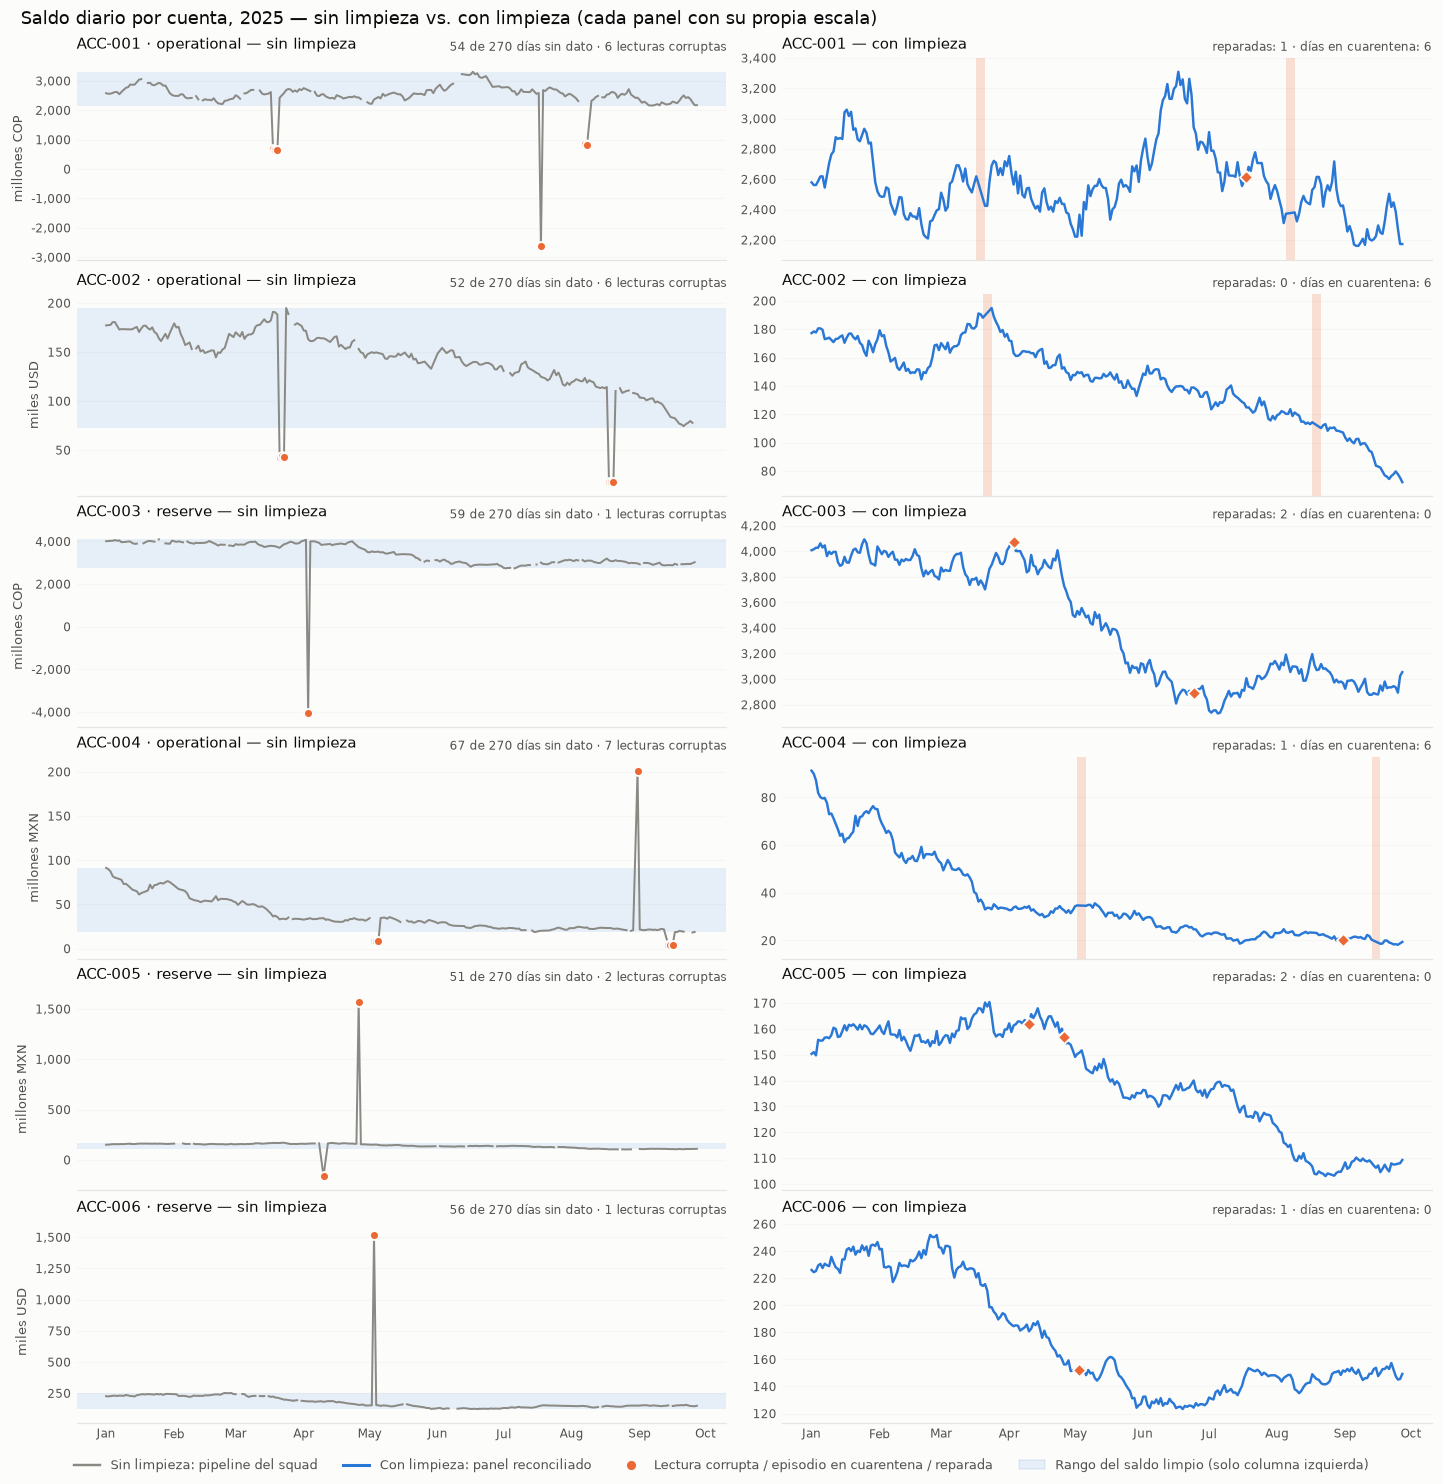

In [6]:
fig = plots.fig_cleaning(data["raw"], panel)
plt.show()

### D2 · Duplicates and sign/scale errors never caught → the squad's forecast is contaminated for 14 days

A single bad value stays inside a 14-day moving average for 14 days. Comparing **the same squad forecast** on its own data vs. on the fixed data isolates the effect of the *data* from the effect of the *method*:


In [7]:
flows = F.net_flow_matrix(panel)
book = P.Book.from_panel(panel)
store = B.ForecastStore(flows, "empirical")          # forecast por origen, sin lookahead, compartido por todas las políticas

contam = D.contamination_table(squad["balances"], panel)
display(contam)
print(f"Días en que el forecast del squad se aleja >10% del forecast sobre datos limpios: {int(contam['dias_con_desvio>10%'].sum())} "
      f"(desvío máximo {contam['desvio_max_%'].max():.0f}%).")

,dias_comparados,dias_con_desvio>10%,desvio_max_%,alertas_con_datos_squad,alertas_con_datos_limpios
account_id,,,,,
ACC-001,101,20,15.04,0.00,0.00
ACC-002,140,7,17.19,11.00,10.00
ACC-003,92,14,14.79,NaN,NaN
ACC-004,126,8,55.64,72.00,73.00
ACC-005,112,16,68.44,NaN,NaN
ACC-006,118,11,65.60,0.00,0.00


Días en que el forecast del squad se aleja >10% del forecast sobre datos limpios: 76 (desvío máximo 68%).


That's the squad's "**ACC-004's forecast sometimes goes haywire day to day**": it's not noise to smooth out — as they planned to do — it's corrupted data entering a window. Adding smoothing would have made it worse.

### D3 · 9 currency labels treated as different currencies
Visible in their own `unique()` in cell 3 (9 labels for 3 currencies). Each account only uses variants of *its own* currency (0 rows in the wrong currency), so it's a labeling problem: `accounts.csv` is the source of truth, normalized to ISO-4217 with cross-validation.

### D4 · The forecast is a 14-day moving average of the **level**: no drift, no seasonality, no horizon
All 6 accounts' balances **trend downward** (negative average net flow); averaging past levels always overestimates them. Backtest (daily origin, 7- and 14-day-ahead balance, clean data) of the squad's forecast against the simplest possible baseline: *"tomorrow's balance = today's."*


* mae_squad — mean absolute error of the squad's forecast (14-day moving average) against the real balance h days later. Higher is worse.
* mae_ultimo — mean absolute error of the naive baseline "today's balance stays the same in h days" (no model at all).
* mae_propuesto — mean absolute error of the proposed forecast (empirical-bootstrap median) against the same real balance.

---

* ultimo/squad — mae_ultimo / mae_squad. This ratio makes the comparison scale-independent (COP vs. USD vs. MXN). 1.0 = tie; < 1 means "today's balance" beats the squad; > 1 means the squad wins.
* propuesto/squad — same ratio for the proposed forecast. Also well below 1: it beats the squad by an even wider margin.
* squad bias (+ = overestimates) — unlike the others, this isn't an absolute value: it's the signed average error (forecast − actual).


mae_squad     mae_ultimo  mae_propuesto  ultimo/squad  propuesto/squad  sesgo del squad (+ = sobreestima)
h  account_id                                                                                                               
7  ACC-001    179,408,073.19 137,165,073.24 143,615,386.78          0.76             0.80                       7,746,898.17
   ACC-002          9,500.29       6,796.28       6,478.85          0.72             0.68                           5,493.17
   ACC-003    129,723,808.16  97,802,766.88  99,773,467.94          0.75             0.77                      60,659,253.84
   ACC-004      2,974,378.23   2,021,411.63   2,435,063.88          0.68             0.82                       2,256,230.81
   ACC-005      5,886,343.94   4,215,279.77   4,216,991.12          0.72             0.72                       3,226,604.10
   ACC-006         10,780.42       7,373.04       7,593.39          0.68             0.70                           5,981.74
14 ACC-001    211,568,637.59 200,816,478.21 213,798,150.73          0.95             1.01                      22,611,433.21
   ACC-002         12,362.45       9,900.57       8,812.94          0.80             0.71                           8,599.95
   ACC-003    175,570,989.21 146,488,568.83 139,088,867.13          0.83             0.79                      96,740,113.86
   ACC-004      4,108,598.97   3,106,893.16   4,148,441.02          0.76             1.01                       3,318,478.52
   ACC-005      7,791,329.40   6,507,568.86   6,444,649.24          0.84             0.83                       5,242,640.74
   ACC-006         15,271.81      11,517.85      12,024.79          0.75             0.79                           8,974.21

'Último saldo' le gana al forecast del squad en 100% de las combinaciones cuenta × horizonte (error 23% menor en promedio), y el squad sobreestima siempre (sesgo > 0 en todas).


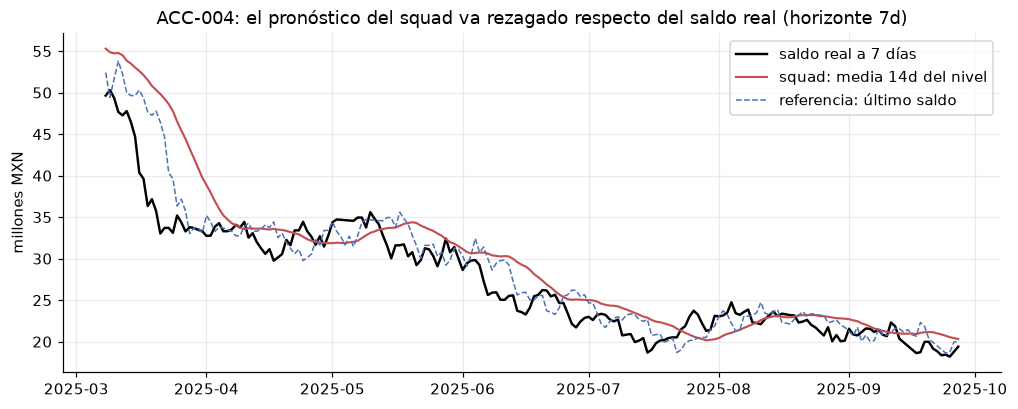

In [8]:
lvl, lvl_series = D.level_forecast_backtest(panel, store)
show = lvl[["account_id", "h", "mae_squad", "mae_ultimo", "mae_propuesto", "mae_ultimo_rel", "mae_propuesto_rel", "sesgo_squad"]].copy()
show = show.rename(columns={"mae_ultimo_rel": "ultimo/squad", "mae_propuesto_rel": "propuesto/squad", "sesgo_squad": "sesgo del squad (+ = sobreestima)"})
display(show.set_index(["h", "account_id"]))
better = (lvl["mae_ultimo"] < lvl["mae_squad"]).mean()
print(f"'Último saldo' le gana al forecast del squad en {better:.0%} de las combinaciones cuenta × horizonte "
      f"(error {(1 - lvl['mae_ultimo_rel']).mean():.0%} menor en promedio), y el squad sobreestima siempre (sesgo > 0 en todas).")
fig = plots.fig_squad_forecast(lvl_series, "ACC-004", 7); plt.show()

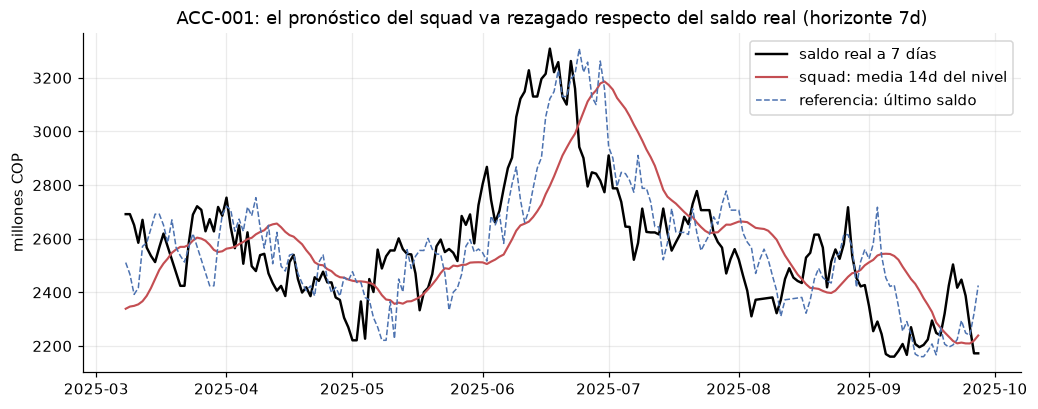

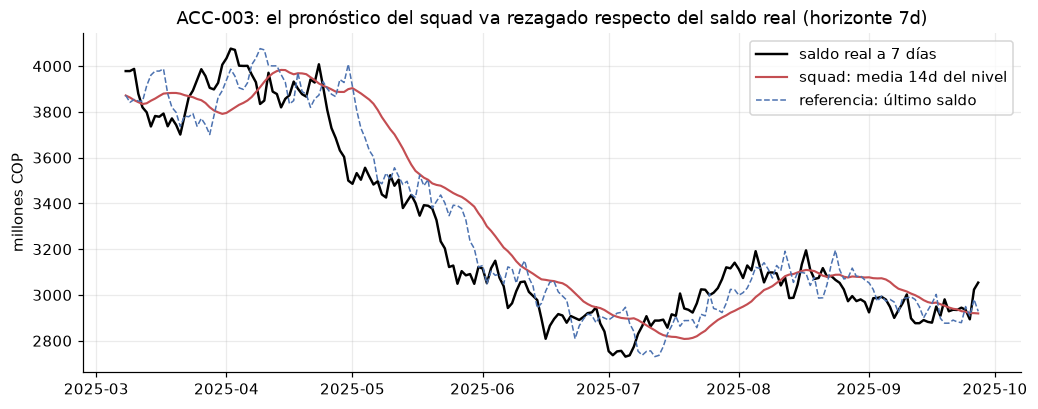

In [9]:
fig = plots.fig_squad_forecast(lvl_series, "ACC-001", 7); plt.show()
fig = plots.fig_squad_forecast(lvl_series, "ACC-003", 7); plt.show()

Honest reading: **at the point level, the best predictor of the balance is "the last balance"** (a random walk with drift), not something sophisticated — Part 2 confirms this. Our contribution isn't a more precise point forecast but **the distribution** (D5). On top of that, the squad's forecast is *worse than not forecasting at all*.


Before moving to D5, a full technical detour worth showing in full, not summarized: is there exploitable weekly structure in the balance? Does modeling with lags (XGBoost) help over ETS? Does a per-account model, tuned with Optuna, beat a global one? **D4b–D4e** answer all three, start to finish.


### D4b · Weekly seasonality: identify it before modeling it

A moving average ignores both trend and the day of week. Before adding seasonality to a model, you have to **confirm it exists, and in which series**. The balance is the accumulated net flow, so its seasonality equals `net_flow`'s: `inflow`, `outflow`, and `net_flow` are all analyzed.

The decision comes from a hypothesis test (**Kruskal-Wallis** across the 7 weekdays, 1% level). STL strength, lag-7 autocorrelation, and the periodogram are supporting evidence. Caveat: STL extracts "seasonality" even from noise (with n = 270, white noise gives ~0.20, p95 ~0.29), so a value in that range proves nothing.


In [10]:
from src import seasonality, tscv

rep = seasonality.weekly_seasonality_report(panel)
view = rep.assign(kruskal_p=rep["kruskal_p"].map("{:.2g}".format)).rename(columns={
    "fuerza_stl_7": "fuerza STL(7)", "acf_rezago_7": "ACF(7)", "banda_95": "±banda 95%",
    "periodo_dominante": "periodo dominante (días)", "kruskal_p": "p Kruskal (día de semana)", "semanal": "¿semanal?"})
display(view)
display(rep["semanal"].unstack("serie")[["inflow", "outflow", "net_flow"]].rename_axis(columns="¿patrón semanal significativo?"))

fuerza STL(7)  ACF(7)  ±banda 95%  periodo dominante (días) p Kruskal (día de semana)  ¿semanal?
account_id serie                                                                                                     
ACC-001    inflow             0.27    0.06        0.12                      6.92                    0.0011       True
           outflow            0.33    0.19        0.12                      7.11                   1.2e-06       True
           net_flow           0.22    0.08        0.12                      8.18                      0.15      False
ACC-002    inflow             0.24    0.09        0.12                      3.51                   9.1e-06       True
           outflow            0.22    0.06        0.12                      3.51                   9.1e-08       True
           net_flow           0.21   -0.05        0.12                      3.75                      0.42      False
ACC-003    inflow             0.61    0.45        0.12                      6.92                   1.2e-20       True
           outflow            0.58    0.46        0.12                      6.92                   5.5e-23       True
           net_flow           0.24   -0.01        0.12                      4.82                      0.89      False
ACC-004    inflow             0.25    0.21        0.12                    270.00                   2.1e-05       True
           outflow            0.04    0.15        0.12                    270.00                      0.53      False
           net_flow           0.00   -0.10        0.12                     30.00                      0.54      False
ACC-005    inflow             0.45    0.36        0.12                      6.92                   3.5e-14       True
           outflow            0.56    0.49        0.12                      6.92                     2e-22       True
           net_flow           0.17    0.01        0.12                      2.18                      0.82      False
ACC-006    inflow             0.39    0.32        0.12                      6.92                   7.4e-12       True
           outflow            0.35    0.30        0.12                      6.92                   8.2e-12       True
           net_flow           0.20    0.03        0.12                      2.13                      0.59      False

¿patrón semanal significativo?,inflow,outflow,net_flow
account_id,,,
ACC-001,True,True,False
ACC-002,True,True,False
ACC-003,True,True,False
ACC-004,True,False,False
ACC-005,True,True,False
ACC-006,True,True,False


**Reading.**

- **Inflows and outflows do have a weekly pattern:** significant in 11 of 12 series (p between 1e-23 and 1e-3). The only exception is ACC-004's outflow (p = 0.53). The periodogram gives ~6.9–7.1 days for ACC-001, 003, 005, and 006; 3.5 for ACC-002 (a harmonic of 7); and trend (270) dominates for ACC-004.
- **The net flow doesn't:** 0 of 6 significant (p between 0.15 and 0.89). Its STL strength (0.00–0.24) is what STL extracts from white noise (~0.20), not a real signal.
- **Why:** inflows and outflows both drop on weekends and cancel out in the net. Since the balance is the accumulated net flow, **the weekly pattern exists in the raw flows but not in the balance**.

Consequence for modeling: an ETS of the balance with weekly seasonality shouldn't help; the seasonality found here can only help if `inflow` and `outflow` are modeled separately. Both are tested below.


#### D4b-1 · Look at the seasonality before testing it

Before running ADF/KPSS and ACF/PACF, it helps to **look** at the series. For each account and each series (balance, inflow, outflow), the average profile is plotted over three cycles:

- **Weekly:** day of week (Monday to Sunday).
- **Bi-weekly:** day within the half-month (1–15 in the first half, 16–31 mapped to 1–16 in the second), to check for payday effects.
- **Monthly:** day of month (1–31).

Each profile is the % deviation from the trend (28-day centered moving average; without removing it, the balance's drift would hide everything), with a ±1.96 standard-error band and the Kruskal-Wallis p-value in the top right (orange if p < 0.01). **If the band covers 0 at almost every position, there's no pattern distinguishable from noise.**

Limits: with ~9 months of data, each weekday has ~38 observations, each half-month position ~17, and each day of month ~9 — so the monthly cycle is the least reliable, and a yearly cycle would need more than a year of history.


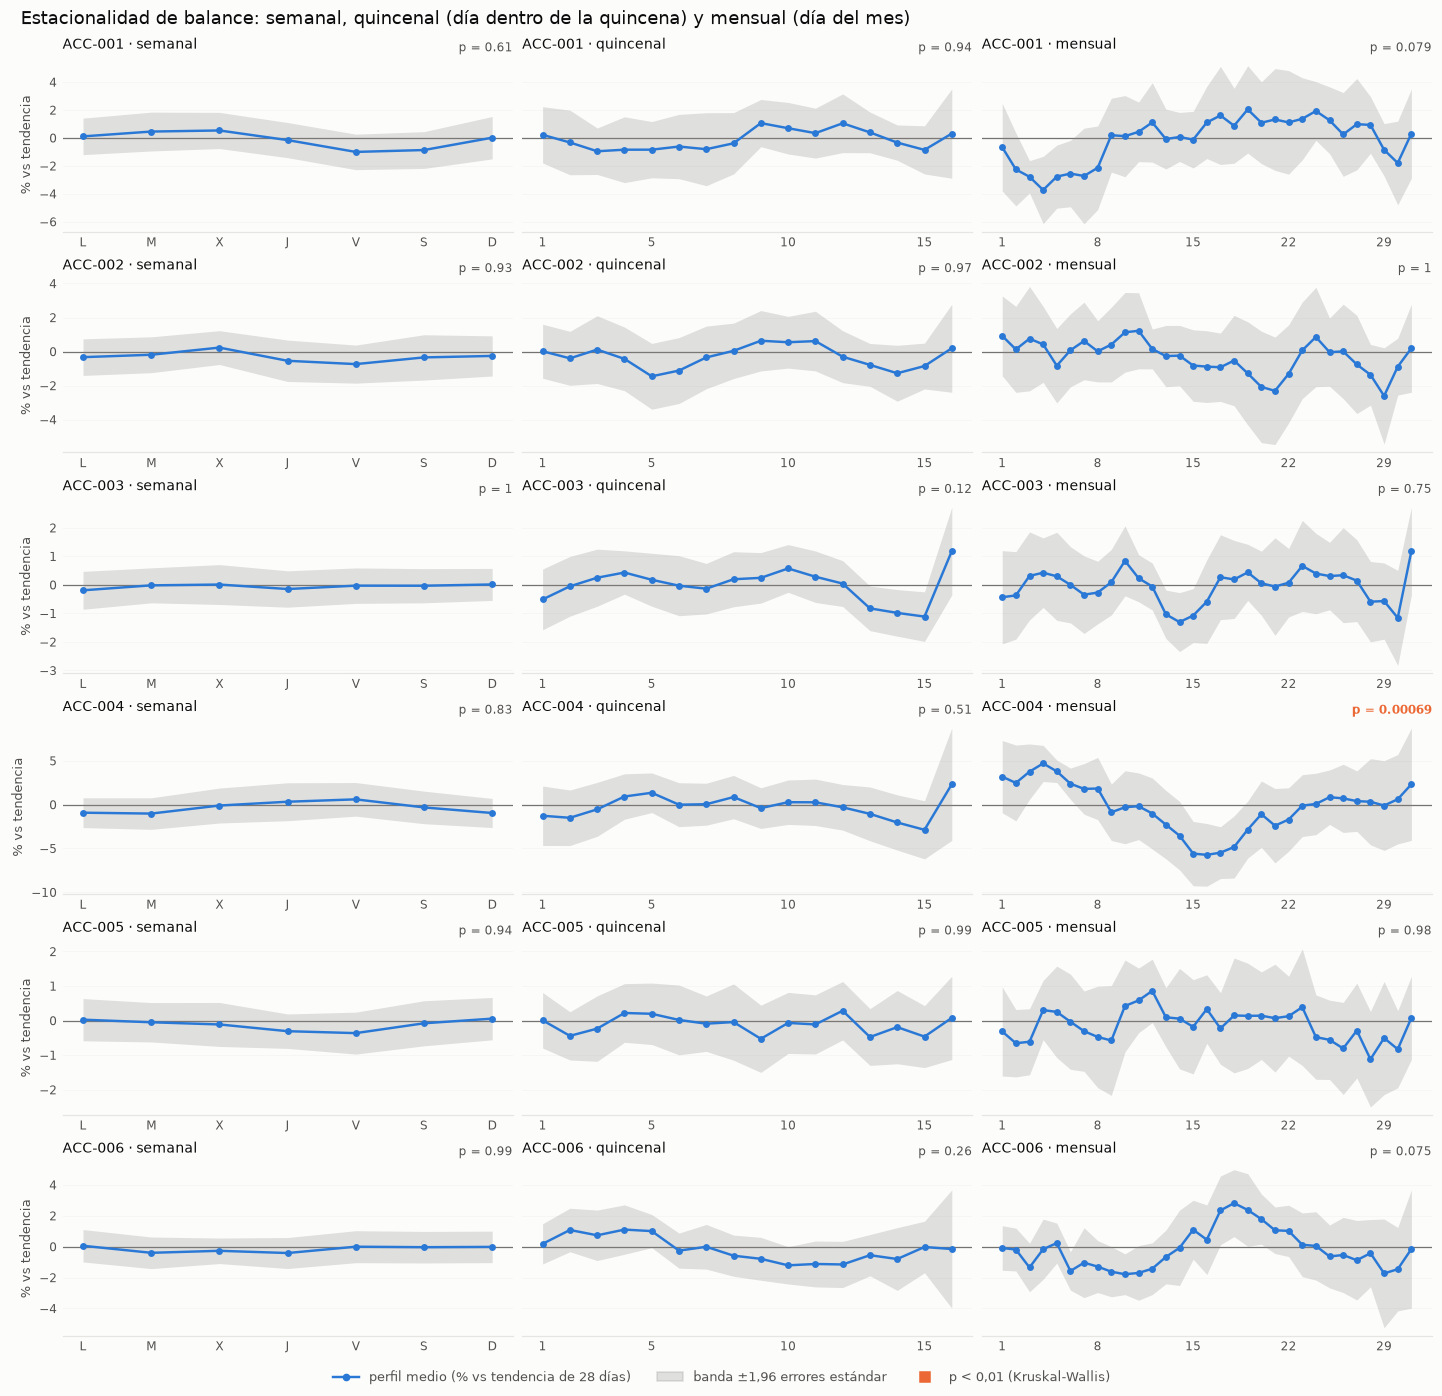

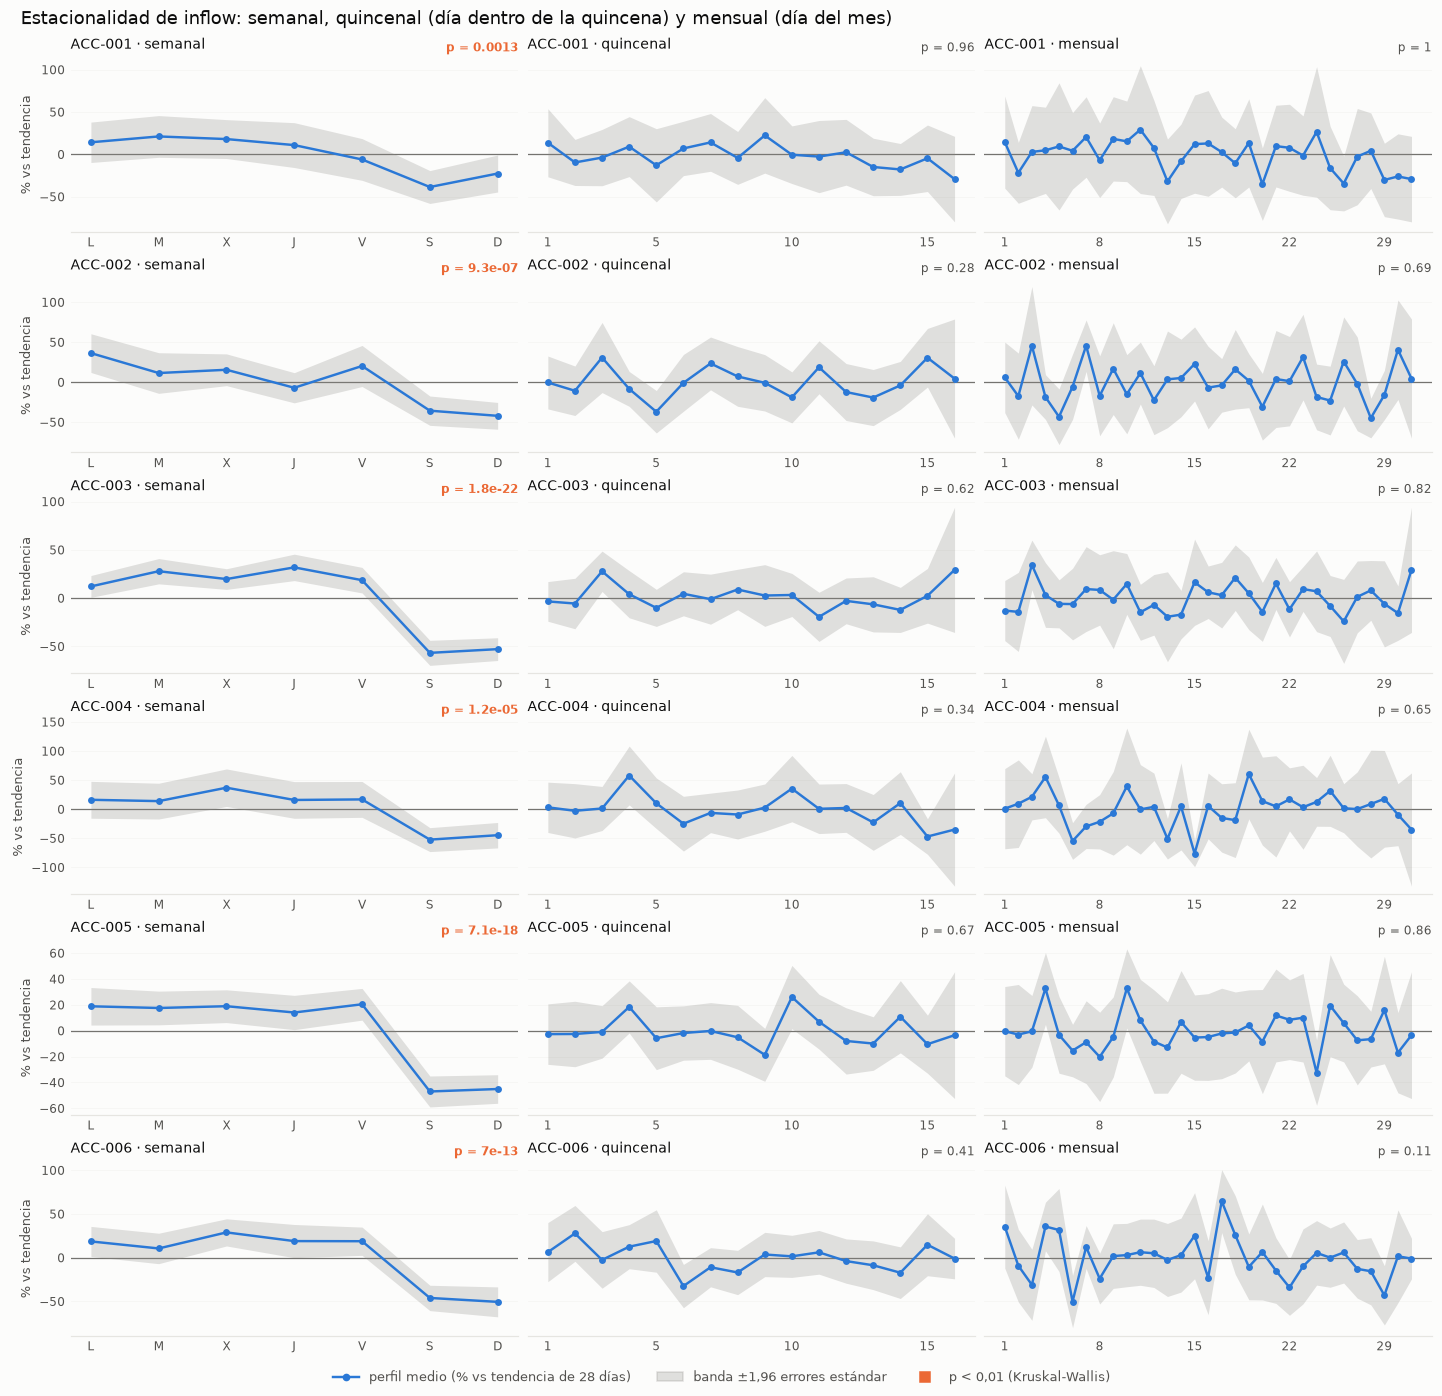

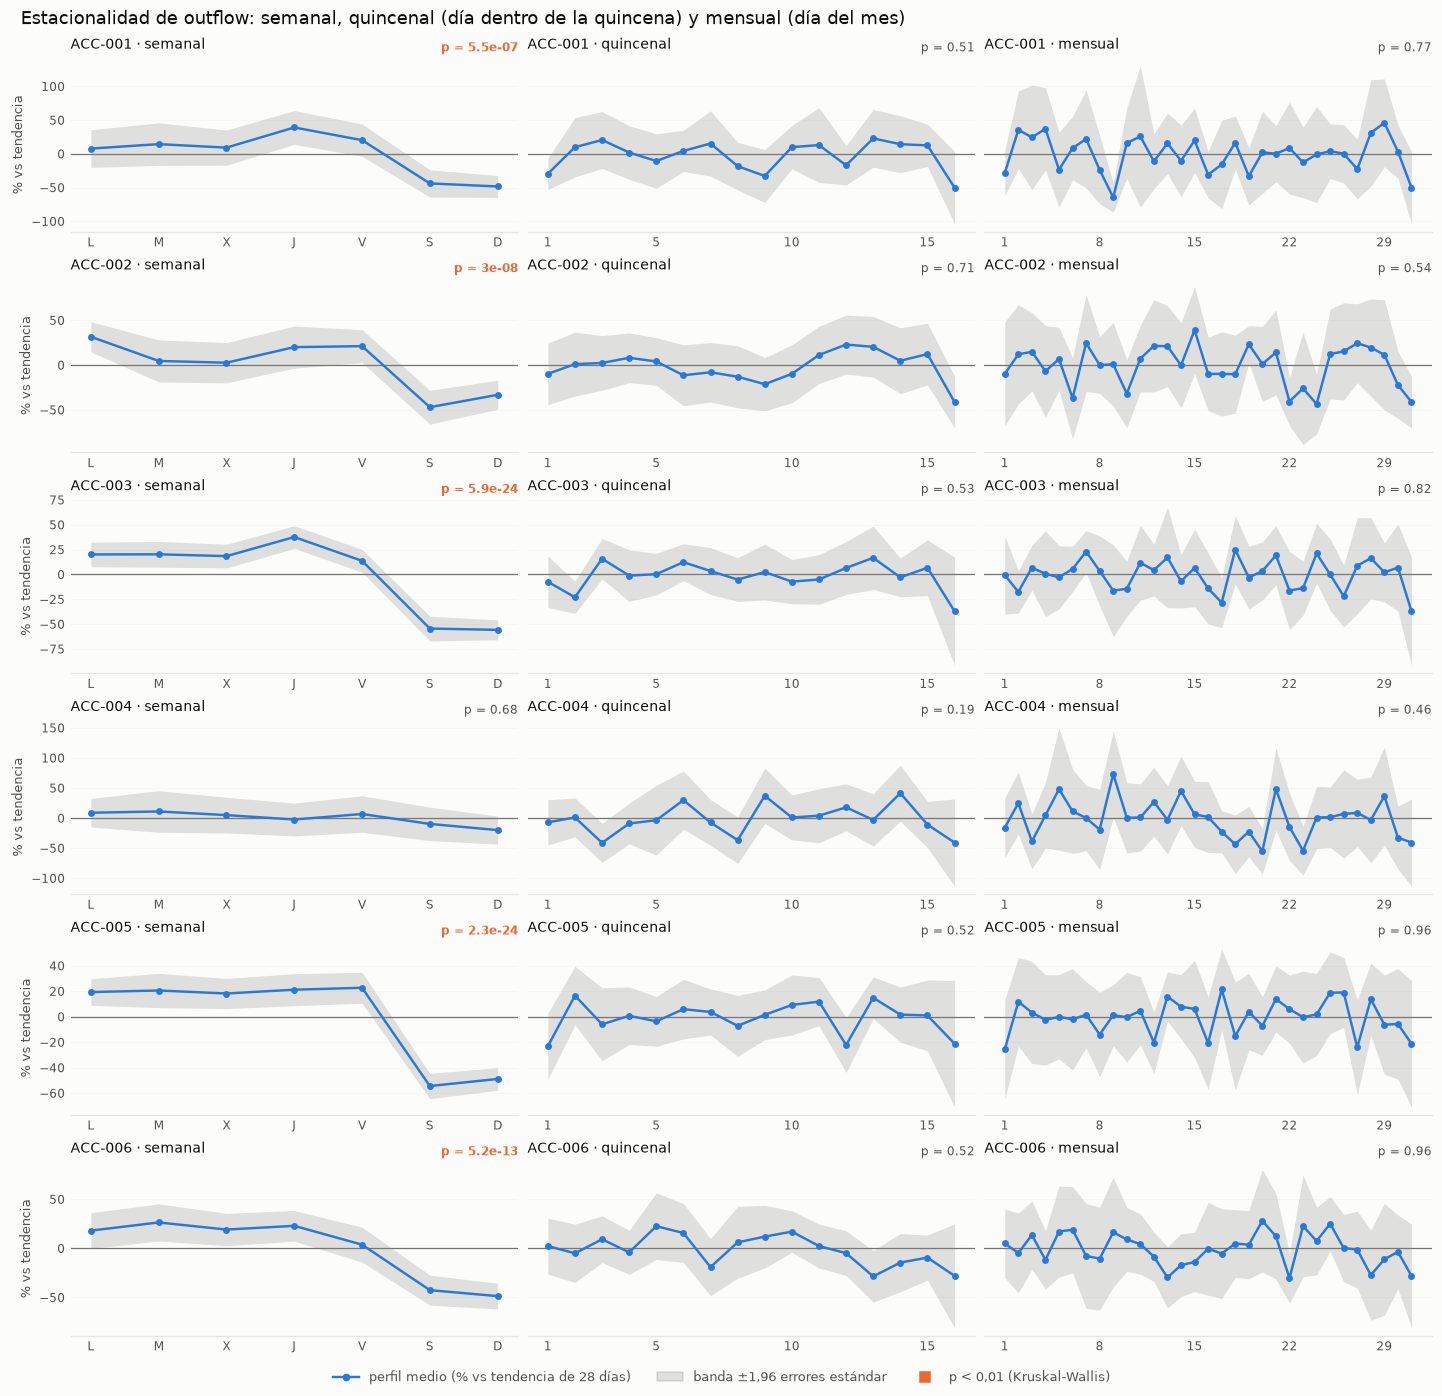

In [11]:
for serie in ("balance", "inflow", "outflow"):
    plots.fig_seasonality(panel, serie); plt.show()

In [12]:
pv = seasonality.cycle_pvalues(panel)
display(pv.map("{:.2g}".format).rename_axis(columns="p-valor (Kruskal-Wallis)"))
print(f"Ciclos quincenal y mensual con p < 0,01: {int((pv[['quincenal', 'mensual']] < 0.01).sum().sum())} de {pv[['quincenal', 'mensual']].size} pruebas "
      f"(por azar se esperaría ~{0.01 * pv[['quincenal', 'mensual']].size:.1f}).")

p-valor (Kruskal-Wallis)  semanal quincenal  mensual
account_id serie                                    
ACC-001    balance           0.61      0.94    0.079
           inflow          0.0013      0.96        1
           outflow        5.5e-07      0.51     0.77
ACC-002    balance           0.93      0.97        1
           inflow         9.3e-07      0.28     0.69
           outflow          3e-08      0.71     0.54
ACC-003    balance              1      0.12     0.75
           inflow         1.8e-22      0.62     0.82
           outflow        5.9e-24      0.53     0.82
ACC-004    balance           0.83      0.51  0.00069
           inflow         1.2e-05      0.34     0.65
           outflow           0.68      0.19     0.46
ACC-005    balance           0.94      0.99     0.98
           inflow         7.1e-18      0.67     0.86
           outflow        2.3e-24      0.52     0.96
ACC-006    balance           0.99      0.26    0.075
           inflow           7e-13      0.41     0.11
           outflow        5.2e-13      0.52     0.96

Ciclos quincenal y mensual con p < 0,01: 1 de 36 pruebas (por azar se esperaría ~0.4).


**Reading.**

- **Weekly is the only cycle with a clear signal, and only in inflow/outflow.** The pattern is significant (p < 0.01) in 11 of 12 flow series; the exception is ACC-004's outflow (p = 0.68). Outflow drops ~33–55% below trend on weekends.
- **The balance has no weekly pattern** (p between 0.6 and 1.0 for all 6 accounts): the weekly effect in inflow/outflow cancels out in the net, and the balance is its cumulative sum.
- **Bi-weekly: no pattern.** No series reaches p < 0.01 (the lowest is 0.12, in ACC-003's balance), and the band covers 0 at almost every position. No payday effect visible.
- **Monthly: one isolated case.** ACC-004's balance dips ~5% around days 12–17 of the month (p = 0.0007) — 1 of 36 bi-weekly/monthly tests, vs. ~0.4 expected by chance, and it lines up with the account the diagnostics notebook already flagged with the strongest ~30-day component. With ~9 observations per day, this is a lead, not a conclusion. ACC-001 and ACC-006 balances show mild wobbles (p ≈ 0.08) that don't reach significance.

**What to expect from ADF and ACF/PACF:** the balance looks like a trend with no seasonality, so it likely isn't stationary in level; inflow/outflow do carry a weekly pattern that needs handling (weekday dummies or a seasonal ETS); there's no bi-weekly or monthly cycle to model, except ACC-004 to keep an eye on.


#### D4b-2 · ACF / PACF: do we need to difference? where is the seasonality?

The weekday test says **whether** there is seasonality; ACF/PACF says **how it behaves** and how to handle the level. Two steps:

1. **Differencing (`d`).** Only differenced if ADF fails to reject a unit root **and** the difference isn't over-differenced (ACF(1) of the difference below −0.25; over-differencing something that didn't need it gives close to −0.5). KPSS is reported as a cross-check.
2. **Seasonality.** On the already-stationary series (the difference if `d = 1`; otherwise the level minus the MSTL trend), look for peaks at lags 7, 14, 21, and 28. Seasonal differencing at lag 7 (`D = 1`) is only used if the seasonal ACF stays high **and** differencing removes it; if it pushes it near −0.5, the pattern is deterministic and should be modeled with dummies, not differences.

Uses the already-clean F1 panel. On raw data, corrupted readings would first need masking, since they distort the ACF (see section 11 of `data_quality_diagnostics.ipynb`).


**Augmented Dickey-Fuller test (ADF).** Decides whether each series needs differencing:

$$
\Delta y_t = \alpha + \beta t + \gamma\, y_{t-1} + \sum_{i=1}^{p} \delta_i \, \Delta y_{t-i} + \varepsilon_t
$$

$$
H_0: \gamma = 0 \ \text{(unit root — non-stationary)}
\qquad\qquad
H_1: \gamma < 0 \ \text{(no unit root — stationary)}
$$

If $p \geq$ `cfg.ADF_ALPHA` (0.05), $H_0$ isn't rejected → difference (`d=1`), unless differencing over-differences the series (ACF(1) of the difference below −0.25) — in that case the level is kept even if ADF suggests differencing. KPSS is reported alongside as a cross-check, not as the decision rule.


In [13]:
diff_t, seas_t, stationary = seasonality.acf_pacf_report(panel)
display(diff_t[["adf_p", "d", "kpss_p", "acf1_dif", "sobrediferenciada", "kpss_confirma"]].rename(columns={
    "adf_p": "ADF p (nivel)", "d": "¿diferenciar? (d)", "kpss_p": "KPSS p (nivel)",
    "acf1_dif": "ACF(1) de la diferencia", "sobrediferenciada": "¿sobrediferenciada?",
    "kpss_confirma": "KPSS confirma"}).round(3))

ADF p (nivel)  ¿diferenciar? (d)  KPSS p (nivel)  ACF(1) de la diferencia  ¿sobrediferenciada?  KPSS confirma
account_id serie                                                                                                                 
ACC-001    balance           0.21                  1            0.10                    -0.05                False          False
           inflow            0.00                  0            0.10                    -0.47                 True           True
           outflow           0.00                  0            0.10                    -0.42                 True           True
ACC-002    balance           0.98                  1            0.01                    -0.05                False           True
           inflow            0.12                  0            0.01                    -0.52                 True          False
           outflow           0.00                  0            0.01                    -0.49                 True          False
ACC-003    balance           0.71                  1            0.01                    -0.00                False           True
           inflow            0.09                  0            0.01                    -0.27                 True          False
           outflow           0.09                  0            0.01                    -0.27                 True          False
ACC-004    balance           0.07                  1            0.01                     0.02                False           True
           inflow            0.00                  0            0.01                    -0.48                 True          False
           outflow           0.00                  0            0.01                    -0.49                 True          False
ACC-005    balance           0.96                  1            0.01                    -0.13                False           True
           inflow            0.37                  0            0.01                    -0.41                 True          False
           outflow           0.62                  0            0.01                    -0.41                 True          False
ACC-006    balance           0.71                  1            0.01                    -0.05                False           True
           inflow            0.31                  0            0.01                    -0.45                 True          False
           outflow           0.35                  0            0.01                    -0.38                 True          False

**Reading.**

- **Balance: differenced once (`d = 1`) for all 6 accounts.** ADF fails to reject a unit root (p from 0.07 to 0.98), confirmed by KPSS in 5 of 6 (ACC-001 is the exception, p = 0.10). The first difference is white noise (ACF(1) between −0.13 and +0.02): the balance behaves like a **random walk with drift**.
- **Inflow/outflow: not differenced (`d = 0`) in any of the 12 series.** Differencing them over-differences (ACF(1) of the difference from −0.27 to −0.52, close to the theoretical −0.5). KPSS rejects level-stationarity in 10 of 12, i.e., they drift slowly — solved by detrending (MSTL), not differencing.
- **Borderline cases:** ACC-003's inflow/outflow (ADF p = 0.09; ACF(1) of the difference = −0.27, just below the −0.25 threshold) are the closest calls.


**Before ACF/PACF: the balance's trend**, via statsmodels' native STL decomposition (observed / trend / seasonal / residual), one figure per account.


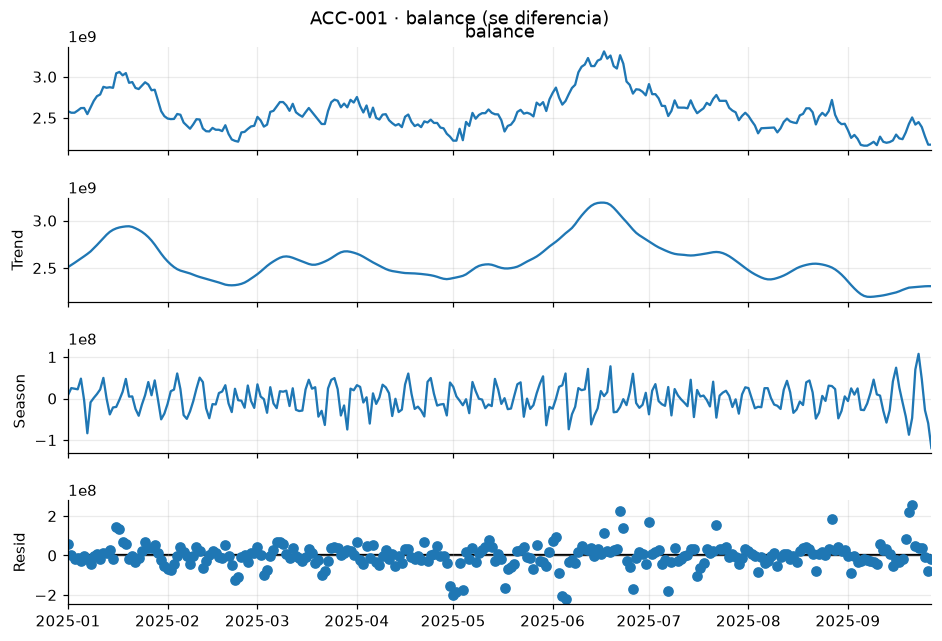

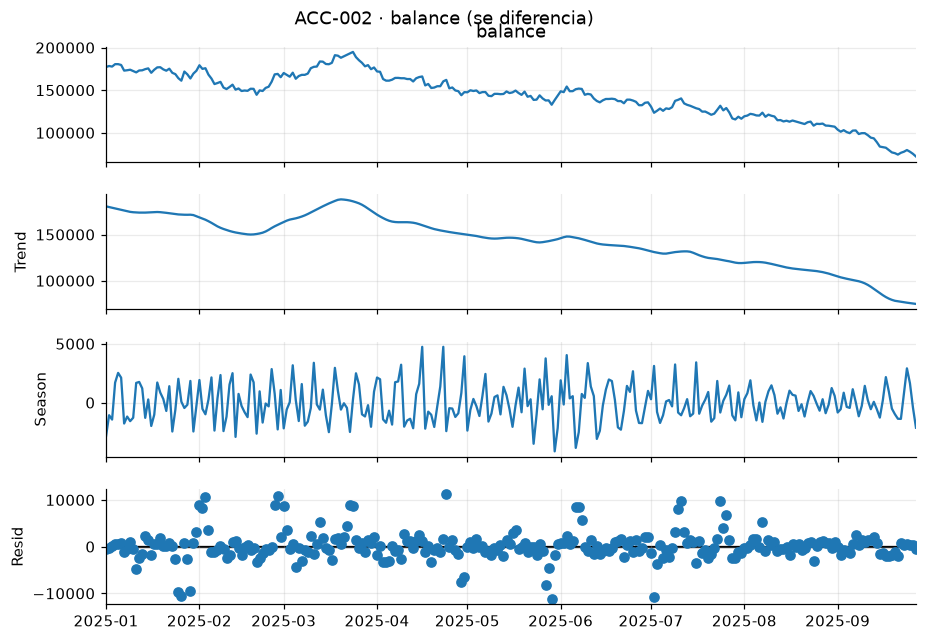

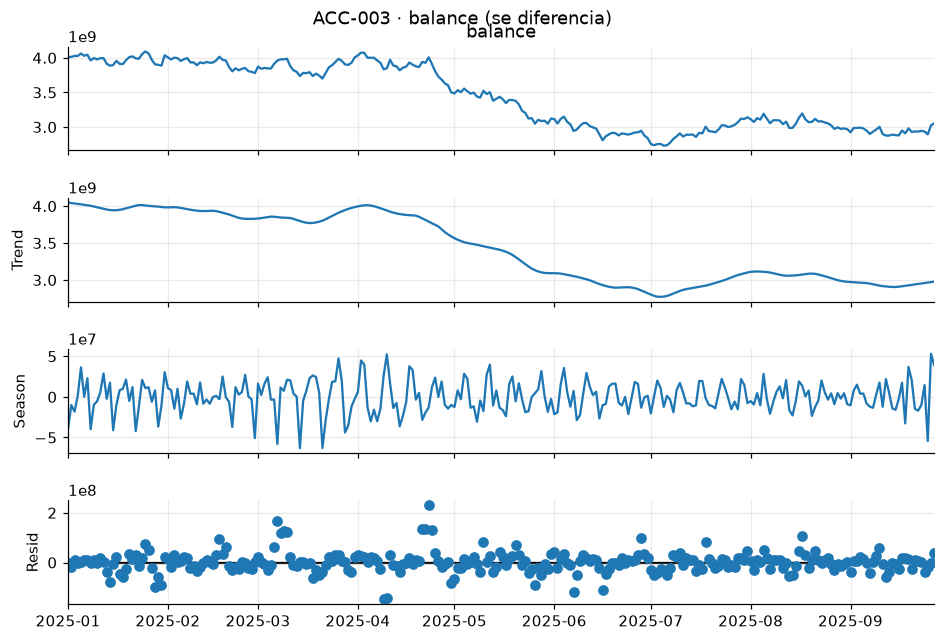

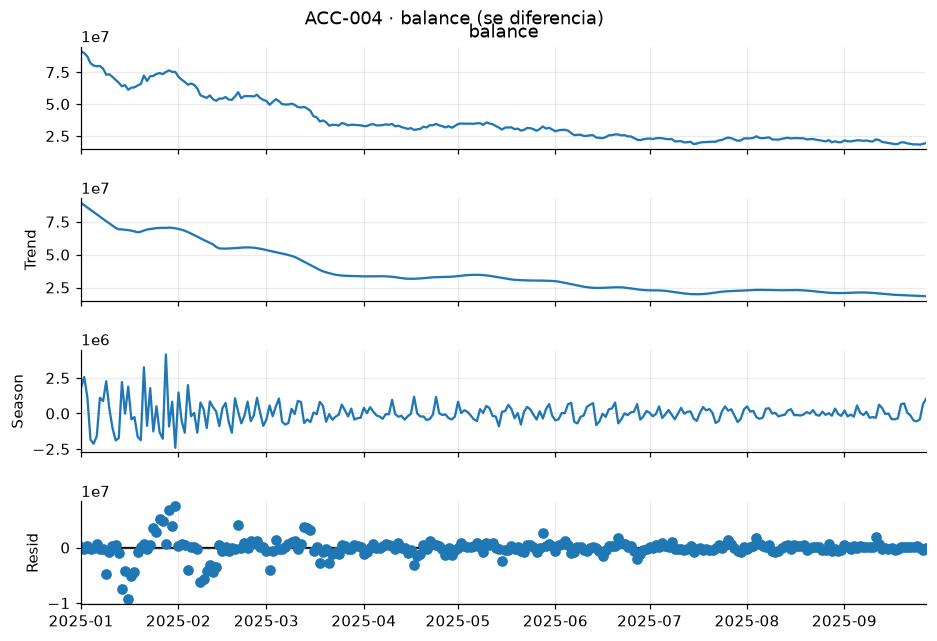

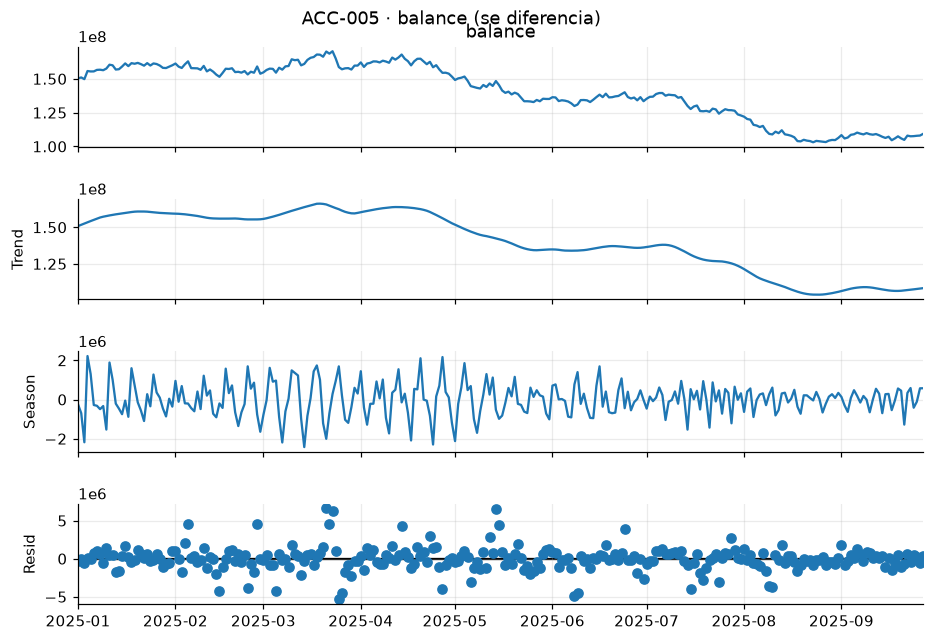

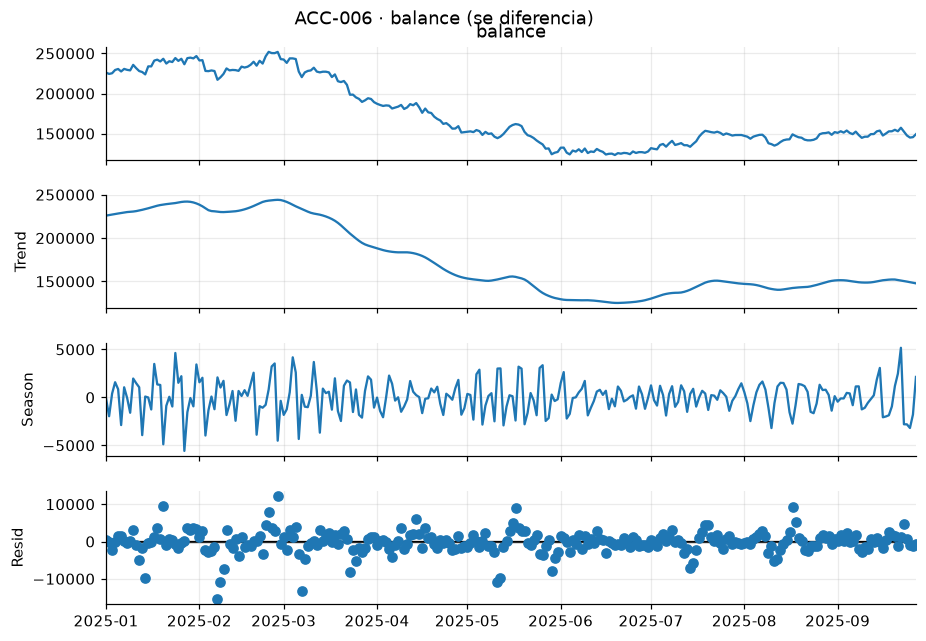

In [14]:
for acc in sorted(panel["account_id"].unique()):
    plots.fig_trend(panel, diff_t, acc); plt.show()

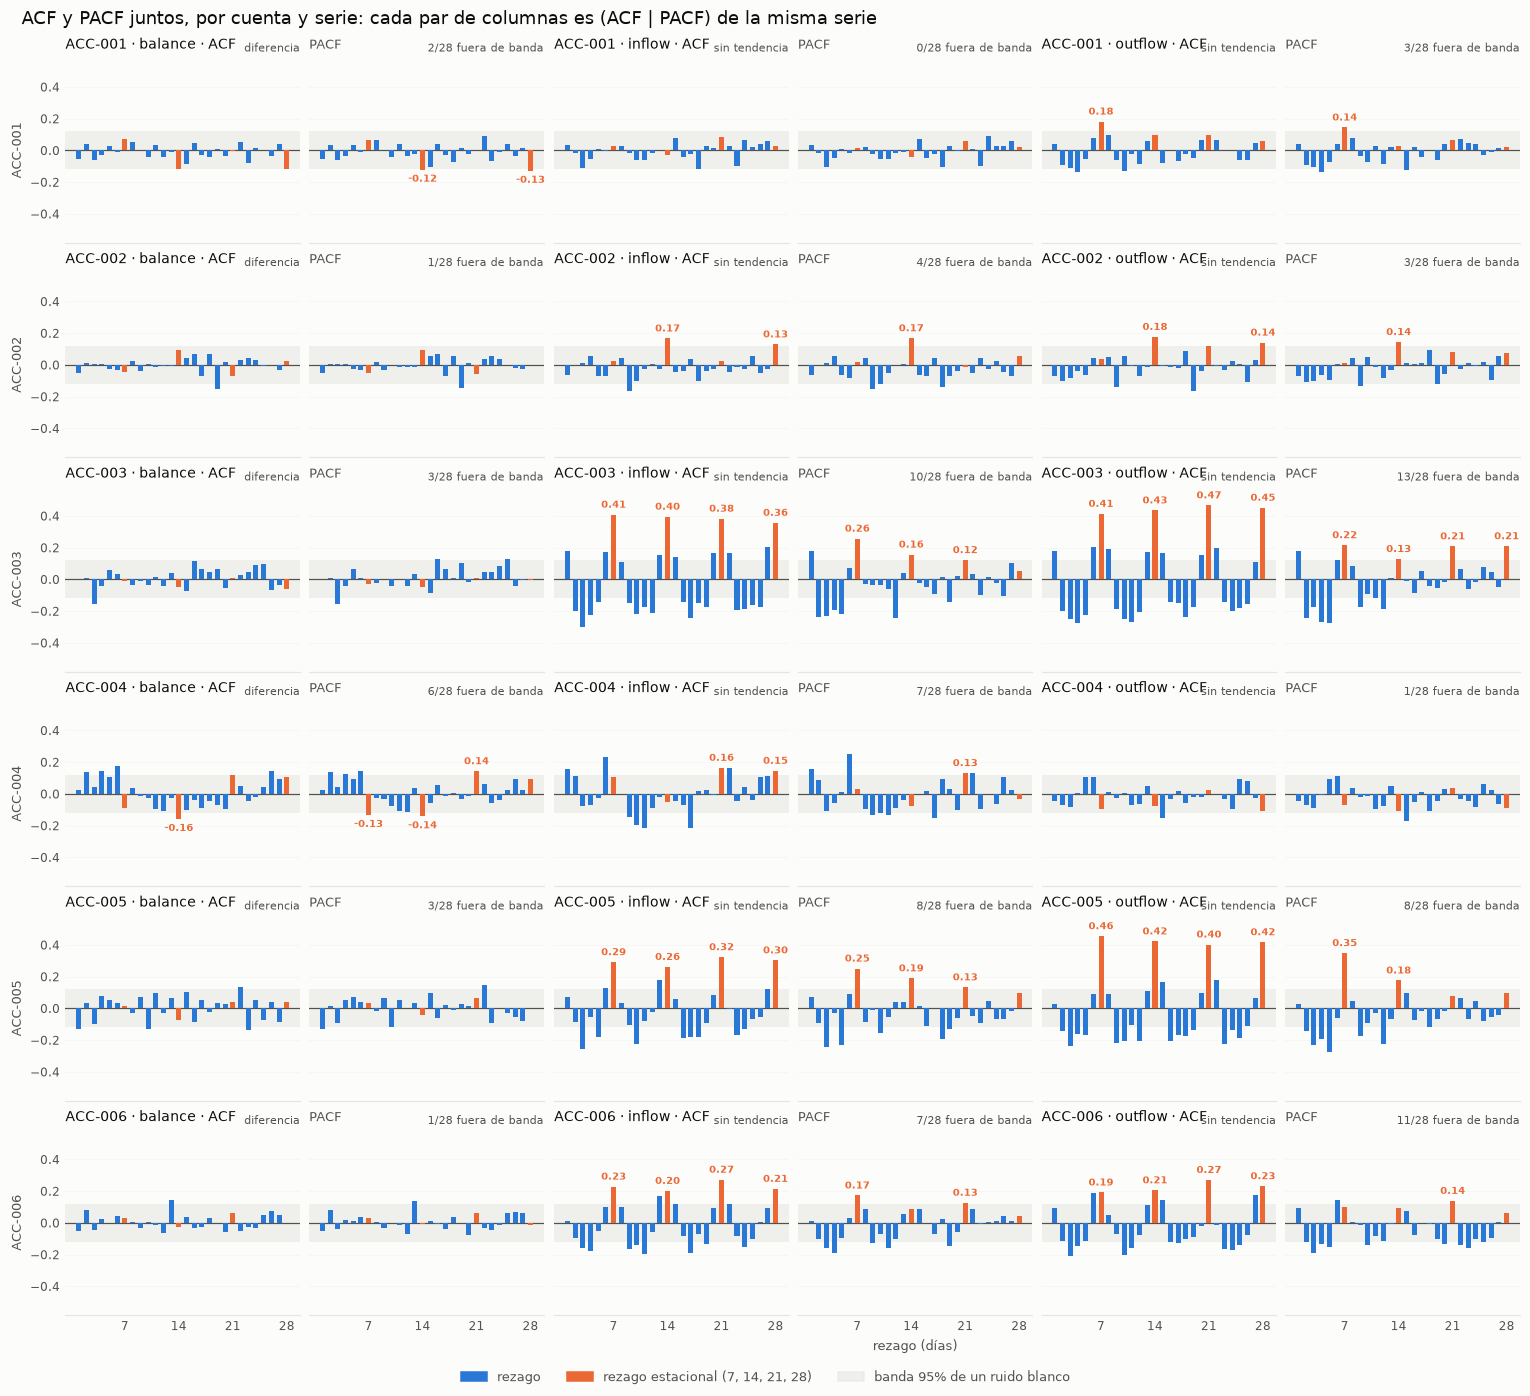

In [15]:
fig = plots.fig_acf_pacf_combined(stationary, diff_t); plt.show()

**Reading.** Orange bars are lags 7, 14, 21, and 28; dashed lines are the white-noise band (±0.12).

- **Balance (differenced):** ACF and PACF stay inside the band at almost every lag, no seasonal peaks: no AR/MA structure and no weekly pattern. The exception is **ACC-004**, which retains some autocorrelation (Ljung-Box p = 0.001).
- **Inflow/outflow for ACC-003, ACC-005, and ACC-006:** the ACF is a **"comb"**: peaks at 7, 14, 21, 28 with negative values in between. The peaks barely decay (ACC-003 inflow: 0.41 / 0.40 / 0.38; ACC-005 outflow: 0.46 / 0.42 / 0.40) — the signature of a **stable, deterministic weekly pattern**, not a seasonal unit root.
- The PACF is significant at lag 7 for almost all of them, but it's not a clean cutoff — some short lags are significant too, as expected when the weekday effect shapes the whole week.


In [16]:
display(seas_t.rename(columns={
    "acf_7": "ACF(7)", "pacf_7": "PACF(7)", "acf_14": "ACF(14)", "acf_21": "ACF(21)", "pico_7": "pico en 7",
    "picos_estacionales": "picos estacionales (de 4)", "ljung_box_p7": "Ljung-Box p (rezago 7)",
    "acf_7_tras_dif_7": "ACF(7) tras dif. en 7", "semanal": "¿semanal?"}).round(3))

d  ACF(7)  PACF(7)  ACF(14)  ACF(21)  pico en 7  picos estacionales (de 4)  Ljung-Box p (rezago 7)  ACF(7) tras dif. en 7  ¿semanal?  D
account_id serie                                                                                                                                           
ACC-001    balance  1    0.07     0.07    -0.12    -0.00       0.06                          0                    0.76                  -0.38      False  0
           inflow   0    0.03     0.02    -0.03     0.09       0.02                          0                    0.71                  -0.46      False  0
           outflow  0    0.18     0.14     0.10     0.10       0.17                          2                    0.00                  -0.44       True  0
ACC-002    balance  1   -0.05    -0.05     0.10    -0.07      -0.03                          0                    0.97                  -0.56      False  0
           inflow   0    0.03     0.02     0.17     0.02       0.09                          2                    0.65                  -0.57      False  0
           outflow  0    0.04     0.01     0.18     0.12       0.06                          3                    0.28                  -0.56      False  0
ACC-003    balance  1   -0.01    -0.03    -0.05     0.01      -0.02                          0                    0.28                  -0.48      False  0
           inflow   0    0.41     0.26     0.40     0.38       0.41                          4                    0.00                  -0.49       True  0
           outflow  0    0.41     0.22     0.43     0.47       0.42                          4                    0.00                  -0.52       True  0
ACC-004    balance  1   -0.09    -0.13    -0.16     0.12      -0.17                          1                    0.00                  -0.46      False  0
           inflow   0    0.11     0.03    -0.05     0.16       0.09                          1                    0.00                  -0.40      False  0
           outflow  0   -0.09    -0.07    -0.08     0.02      -0.14                          0                    0.09                  -0.49      False  0
ACC-005    balance  1    0.01     0.03    -0.07     0.04      -0.02                          0                    0.18                  -0.45      False  0
           inflow   0    0.29     0.25     0.26     0.32       0.32                          4                    0.00                  -0.49       True  0
           outflow  0    0.46     0.35     0.42     0.40       0.51                          4                    0.00                  -0.47       True  0
ACC-006    balance  1    0.03     0.03    -0.03     0.06       0.03                          0                    0.76                  -0.46      False  0
           inflow   0    0.23     0.17     0.20     0.27       0.23                          4                    0.00                  -0.48       True  0
           outflow  0    0.19     0.10     0.20     0.27       0.18                          4                    0.00                  -0.50       True  0

**Conclusion.** A weekly peak counts if the lag-7 ACF stands out from its neighbors beyond the noise band, and at least two of the four seasonal lags stand out.

- **Weekly seasonality in 7 of 12 flow series:** inflow/outflow for ACC-003, ACC-005, ACC-006, plus ACC-001's outflow (weaker, peak of 0.17). **No balance series has it**, nor do the inflows of ACC-001, ACC-002, and ACC-004.
- **No seasonal differencing (`D = 0`) for any series.** Differencing at lag 7 pushes ACF(7) to between −0.38 and −0.57 (over-differencing), and the peaks above don't decay: the weekly pattern is modeled with **weekday dummies or a seasonal ETS**, not removed by differencing.
- **Recommendation by series type:** balance = `d = 1`, no seasonality (random walk with drift); inflow/outflow = `d = 0`, `D = 0`, plus a weekday effect wherever the table flags it.

This explains D4c: since the balance has no structure beyond drift, "the last balance" is very hard to beat, and forcing weekly seasonality onto the balance doesn't help. ACF/PACF is a conservative detector: D4b's weekday test flags 11 of 12 flow series, and ACF/PACF confirms the 7 strongest, also showing what the pattern looks like.


### D4c · Validation with `TimeSeriesSplit` and an ETS forecast

`TimeSeriesSplit` (scikit-learn) uses an **expanding window**: each split trains on everything up to an origin date and tests on the following 14-day block. Test blocks don't overlap and never precede training. Compared against the real, cleaned balance:

- `squad_sin_limpiar` (the baseline) and `squad_limpio`: average of the last 14 rows/days.
- `ultimo_saldo`: the origin balance, unchanged.
- `ets_nivel`: ETS of the balance with damped trend, **no** seasonality.
- `ets_nivel_semanal`: the same, with weekly seasonality **forced on**.
- `ets_flujos`: ETS of `inflow` and `outflow` separately, with weekly seasonality only if the test detects it in that split's **training** window.

Ratios are the block's MAE over `squad_sin_limpiar`'s MAE (below 1 = better).


In [17]:
detail, info = tscv.cv_level_forecasts(panel, squad["balances"])
S = tscv.cv_summary(detail)

# cómo quedó el split: ventana expansiva, un bloque de prueba de 14 días por corte
all_days = pd.DatetimeIndex(sorted(panel["date"].unique()))
folds = detail.groupby("fold").agg(origen=("origen", "first"), prueba_desde=("date", "min"), prueba_hasta=("date", "max"))
folds.insert(1, "días de entrenamiento", [int((all_days <= o).sum()) for o in folds["origen"]])
display(folds)

print("Global (razón media entre cuentas vs squad sin limpiar; <1 = mejor):")
display(S["global"])
print("Por corte (razón media entre cuentas): ¿el resultado es estable en el tiempo?")
display(S["por_corte"])
print("Por cuenta (razón vs squad sin limpiar):")
display(S["por_cuenta"]["razon_vs_base"].unstack("model")[list(tscv.MODELS)])
print("warnings de convergencia de los ETS (contados, no silenciados):", info["n_warnings"])

,origen,días de entrenamiento,prueba_desde,prueba_hasta
fold,,,,
1,2025-07-19,200,2025-07-20,2025-08-02
2,2025-08-02,214,2025-08-03,2025-08-16
3,2025-08-16,228,2025-08-17,2025-08-30
4,2025-08-30,242,2025-08-31,2025-09-13
5,2025-09-13,256,2025-09-14,2025-09-27


Global (razón media entre cuentas vs squad sin limpiar; <1 = mejor):


,razon_media_vs_base,cuentas_que_mejoran_a_base
model,,
squad_sin_limpiar,1.00,0
squad_limpio,0.81,5
ultimo_saldo,0.55,6
ets_nivel,0.57,6
ets_nivel_semanal,0.57,6
ets_flujos,0.62,5


Por corte (razón media entre cuentas): ¿el resultado es estable en el tiempo?


model,origen,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos
fold,,,,,,,
1,2025-07-19,1.00,0.90,0.60,0.63,0.58,0.87
2,2025-08-02,1.00,1.00,0.60,0.61,0.66,0.63
3,2025-08-16,1.00,0.92,0.84,0.83,0.87,1.03
4,2025-08-30,1.00,0.87,0.66,0.75,0.74,0.95
5,2025-09-13,1.00,0.87,0.94,0.95,0.92,1.03


Por cuenta (razón vs squad sin limpiar):


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos
account_id,,,,,,
ACC-001,1.00,0.62,0.43,0.43,0.43,0.44
ACC-002,1.00,0.92,0.56,0.56,0.57,0.25
ACC-003,1.00,0.96,0.76,0.76,0.77,0.96
ACC-004,1.00,0.32,0.30,0.32,0.32,0.41
ACC-005,1.00,0.97,0.52,0.51,0.50,0.67
ACC-006,1.00,1.06,0.70,0.82,0.83,1.00


warnings de convergencia de los ETS (contados, no silenciados): {'squad_sin_limpiar': 0, 'squad_limpio': 0, 'ultimo_saldo': 0, 'ets_nivel': 0, 'ets_nivel_semanal': 0, 'ets_flujos': 0}


- **The split:** 5 expanding-window cuts. Training grows from 200 to 256 days; test blocks span Jul 20–Sep 27, in 14-day chunks.
- **Every new model beats the squad on uncleaned data:** 38–45% lower error (ratios 0.55–0.62). Cleaning the data alone already cuts the moving-average error by 19% (0.81), improving 5 of 6 accounts (ACC-006 gets worse: 1.06).
- **Weekly seasonality doesn't help the balance, as D4b predicted:** `ets_nivel_semanal` (0.57) ties `ets_nivel` (0.57). And the trended ETS **doesn't beat "the last balance"** (0.57 vs. 0.55).
- **`ets_flujos` is uneven:** best of all on ACC-002 (0.25 vs. 0.56 for the level ETS), but it doesn't beat the squad on ACC-003 (0.96) or ACC-006 (1.00). On average (0.62) it's worse than the balance ETS. It picked up the weekly pattern in inflow/outflow in almost every split (except ACC-004's outflow), consistent with D4b.
- **The advantage shrinks over time:** in the last split (origin Sep 13), everything lands between 0.87 and 1.03 — `ultimo_saldo` at 0.94, `ets_nivel` at 0.95, `ets_flujos` at 1.03.

**Honest conclusion:** weekly seasonality is clearly present, but it **doesn't help forecast the 14-day balance level**. Almost all of the improvement over the squad already comes from "the last balance," which uses neither seasonality nor trend — it comes from not averaging stale levels or corrupted data. With only 5 splits × 14 days × 6 accounts, the evidence is thin: the gap between `ultimo_saldo` and the ETS models is a technical tie. Any value from weekly seasonality would live in the daily flows, which this validation doesn't measure.


### D4d · XGBoost with lags: over-, under-, or well-balanced (±15%)?

A model from a different family (gradient-boosted trees), validated on the **same `TimeSeriesSplit` cuts** as D4c for a fair comparison.

- **One global model** for all 6 accounts. Everything is normalized by each account's 28-day average outflow (*days of outflow*), making COP, MXN, and USD comparable.
- **Direct strategy:** the target is the balance change h days out, `(balance[t+h] − balance[t]) / scale[t]`, with h = 1…14 as a feature. The balance forecast is `balance[t] + ŷ · scale[t]`.
- **Features (at t, past only):** net-flow lags 0–6, inflow/outflow at lags 0 and 7, rolling mean/std of the net flow, coverage in days, origin and target weekday, and account type.
- **No leakage:** each split only trains on targets that fall inside the training window (a test checks that altering anything after the origin date doesn't change the forecast). Hyperparameters are fixed and modest, **not tuned on the test splits**.

**How to read the table.** With `rel = (forecast − actual) / actual`: **overestimates** if `rel > +15%` (real balance is lower than expected: shortfall risk), **underestimates** if `rel < −15%` (money would move unnecessarily), and **balanced** otherwise. MAPE = mean of |rel|; sMAPE = mean of 2|F−A|/(|F|+|A|).

**`MAE (days of outflow)`** = `|forecast − actual| / scale`, with `scale` = that account's average outflow over the trailing 28 days at the forecast origin (same normalization as the *direct strategy* above). This isn't a MAE in pesos/dollars — those can't be averaged across COP, MXN, and USD without the largest-balance account dominating the number. Dividing by each account's typical daily spend puts the error in a common unit: "days of outflow that error represents." E.g., MAE = 1.4 means the forecast is off, on average, by the equivalent of 1.4 days of that account's normal spending.


In [18]:
from src import ml_forecast

detail_x = ml_forecast.cv_xgb(panel)                          # mismos cortes que D4c
detail_all = pd.concat([detail, detail_x], ignore_index=True)
order = list(tscv.MODELS) + ["xgboost"]

print("Todas las cuentas juntas, banda ±15%:")
display(ml_forecast.error_table(detail_all, panel).loc[order])
print("La misma tabla con banda ±5% (la de ±15% es muy holgada para un saldo a 14 días o menos):")
display(ml_forecast.error_table(detail_all, panel, band=0.05).loc[order].iloc[:, :7])

Todas las cuentas juntas, banda ±15%:


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+15%),balanceado % (±15%),subestima % (<-15%),n
model,,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,9.76,86.43,3.81,420
squad_limpio,2.02,6.31,6.07,3.16,7.14,92.86,0.00,420
ultimo_saldo,1.40,4.36,4.26,1.56,3.10,96.90,0.00,420
ets_nivel,1.45,4.46,4.36,1.60,3.10,96.90,0.00,420
ets_nivel_semanal,1.46,4.50,4.39,1.88,3.33,96.67,0.00,420
ets_flujos,1.53,4.49,4.50,0.17,0.95,97.38,1.67,420
xgboost,1.36,4.18,4.17,-0.10,2.14,96.67,1.19,420


La misma tabla con banda ±5% (la de ±15% es muy holgada para un saldo a 14 días o menos):


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+5%),balanceado % (±5%),subestima % (<-5%)
model,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,34.76,43.81,21.43
squad_limpio,2.02,6.31,6.07,3.16,36.67,50.00,13.33
ultimo_saldo,1.40,4.36,4.26,1.56,19.76,70.24,10.00
ets_nivel,1.45,4.46,4.36,1.60,22.38,66.90,10.71
ets_nivel_semanal,1.46,4.50,4.39,1.88,24.76,66.43,8.81
ets_flujos,1.53,4.49,4.50,0.17,18.10,67.14,14.76
xgboost,1.36,4.18,4.17,-0.10,14.52,68.81,16.67


In [19]:
by_acc = ml_forecast.error_table(detail_all, panel, by=("account_id", "model"))
for col in ["MAPE %", "sMAPE %", "balanceado % (±15%)", "sesgo % (+ = sobreestima)"]:
    print(col)
    display(by_acc[col].unstack("model")[order])
w, n = ml_forecast.block_wins(detail_all, "xgboost", "ultimo_saldo")
print(f"XGBoost tiene menor MAE que el último saldo en {w} de {n} bloques (corte × cuenta).")
display(ml_forecast.feature_importance(panel).rename("importancia (ganancia)").to_frame())

MAPE %


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,11.21,7.22,4.94,4.97,5.01,5.05,4.99
ACC-002,12.21,11.22,7.02,6.97,7.07,2.98,5.74
ACC-003,2.91,2.81,2.22,2.22,2.22,2.78,2.61
ACC-004,21.53,6.55,6.01,6.31,6.43,8.13,5.94
ACC-005,6.41,6.25,3.43,3.31,3.29,4.35,3.31
ACC-006,3.61,3.82,2.53,2.96,2.99,3.64,2.46


sMAPE %


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,11.41,7.01,4.89,4.92,4.93,4.97,5.04
ACC-002,11.44,10.27,6.57,6.53,6.62,2.91,5.41
ACC-003,2.93,2.82,2.23,2.23,2.23,2.80,2.66
ACC-004,16.51,6.43,6.01,6.33,6.37,8.26,6.08
ACC-005,6.16,6.02,3.36,3.26,3.23,4.47,3.31
ACC-006,3.65,3.85,2.52,2.93,2.97,3.57,2.50


balanceado % (±15%)


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,70.00,88.57,100.00,100.00,100.00,100.00,100.00
ACC-002,77.14,78.57,84.29,84.29,84.29,100.00,87.14
ACC-003,100.00,100.00,100.00,100.00,100.00,100.00,100.00
ACC-004,77.14,94.29,97.14,97.14,95.71,84.29,92.86
ACC-005,94.29,95.71,100.00,100.00,100.00,100.00,100.00
ACC-006,100.00,100.00,100.00,100.00,100.00,100.00,100.00


sesgo % (+ = sobreestima)


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,-1.55,2.96,1.02,1.05,1.76,1.62,-0.81
ACC-002,7.08,11.18,6.47,6.41,6.51,1.88,4.85
ACC-003,-0.42,-0.35,-0.35,-0.35,-0.30,-0.45,-1.56
ACC-004,17.11,1.94,0.11,0.07,1.02,-1.04,-1.91
ACC-005,4.87,4.68,1.86,1.60,1.60,-2.49,0.13
ACC-006,-1.70,-1.43,0.27,0.86,0.72,1.50,-1.29


XGBoost tiene menor MAE que el último saldo en 18 de 30 bloques (corte × cuenta).


,importancia (ganancia)
neto_media14,0.09
neto_std14,0.08
neto_media28,0.08
horizonte_h,0.08
cobertura_dias,0.06
es_reserva,0.06
entrada_lag7,0.05
neto_lag2,0.05
salida_lag0,0.05
salida_lag7,0.05


**Reading.**

- **XGBoost has the lowest error, but barely.** MAE of 1.36 days of outflow, MAPE 4.18%, sMAPE 4.17%, vs. 1.40 / 4.36 / 4.26 for "last balance." It wins **18 of 30 blocks (60%)** — a technical tie, not a real edge.
- **Over/under/balanced (±15% band).** The squad on uncleaned data is balanced 86.4% of the time: overestimates 9.8%, underestimates 3.8%, with a +4.2% bias (+17% for ACC-004). Cleaning the data raises balance to 92.9% and removes underestimation. XGBoost is 96.7% balanced (2.1% over, 1.2% under) with the most neutral bias (−0.10%); last balance is 96.9%.
- **The ±15% band is very loose** for a 14-day-or-less balance forecast: almost everything falls inside it (97%). At ±5% the differences show up: 43.8% balanced (uncleaned squad) → 50.0% (cleaned) → 70.2% (last balance) → 68.8% (XGBoost). XGBoost overestimates less (14.5% vs. 19.8%) but underestimates more (16.7% vs. 10.0%): **it shifts the type of error more than it reduces it**.
- **Error concentrates in ACC-002 and ACC-004:** the only accounts where any model falls below 100% balanced at ±15%. For ACC-002 the best is `ets_flujos` (MAPE 2.98% vs. 5.74% for XGBoost); for the other accounts no model beats "last balance."
- **Feature importance is spread out** (the top one doesn't exceed 9%: rolling mean/std of the net flow, horizon, coverage), with no dominant feature — the signature of a weak signal. Weekly lags of inflow/outflow contribute ~5% each.

**What this means for rebalancing.** Overestimating the balance is the dangerous direction (shortfall risk); underestimating it costs unnecessary transfers. What's clear is that the squad's model on uncleaned data systematically overestimates, and swapping in XGBoost barely improves on "last balance." So **the value isn't a better point forecast — it's the distribution (quantiles) and the decision rule** (B, C, D). Also, XGBoost only outputs a point forecast: feeding the quantile policy would need a quantile model or a bootstrap of its residuals. Limits: 5 splits × 14 days × 6 accounts (420 correlated forecasts) over the last 70 days.


### D4e · The challenge: one model per account (not one global model), tuned — does it improve MAPE?

D4d uses **a single** XGBoost for all 6 accounts. The obvious question: does a dedicated model per series — with its own hyperparameters — beat a generic one? Tested with LightGBM, same feature mechanics and direct strategy as D4d (`src/ml_forecast.py`), but:

- **One model per account**, not pooled: `ml_forecast.cv_lgbm(panel, tuned_params=...)`.
- **Tuned with Optuna** (TPE, 30 trials per account) — unlike D4d, where `cfg.XGB_PARAMS` is fixed *on purpose* ("not tuned on the test splits"). Here tuning does happen, but without touching the reported splits: `ml_forecast.tune_lgbm_per_account` runs an internal CV that **finishes before the outer CV** used in D4c/D4d starts (day 200 of 270, `ml_forecast.outer_cv_first_test_start`). No hyperparameter could have seen any of the 5 splits compared below — a test (`test_tune_lgbm_never_sees_the_outer_test_folds`) verifies this by altering the data from that day onward and confirming the choice doesn't change.
- **A control:** `ml_forecast.cv_lgbm_pooled` — pooled LightGBM, like XGBoost, with **untuned** default parameters. This isolates whether a worse result comes from the *algorithm* (LightGBM vs. XGBoost) or from *splitting the data* into 6 models: here only the algorithm changes, everything else matches D4d.


In [20]:
best_params, search = ml_forecast.tune_lgbm_per_account(panel)   # ~15-20 s: 30 pruebas de Optuna x 6 cuentas
print(f"Mejor MAE interno (normalizado, CV antes del día {ml_forecast.outer_cv_first_test_start(len(panel['date'].unique()))}) por cuenta:")
display(search.loc[search["elegido"]].set_index("account_id")[["mae_norm_interno", "n_estimators", "learning_rate", "num_leaves", "min_child_samples", "reg_lambda"]].round(4))

Mejor MAE interno (normalizado, CV antes del día 200) por cuenta:


,mae_norm_interno,n_estimators,learning_rate,num_leaves,min_child_samples,reg_lambda
account_id,,,,,,
ACC-001,2.72,54,0.01,20,17,7.85
ACC-002,1.86,186,0.04,30,38,2.68
ACC-003,1.22,115,0.02,3,18,2.85
ACC-004,1.30,384,0.09,14,39,2.06
ACC-005,0.88,320,0.05,14,28,20.17
ACC-006,1.68,57,0.01,22,40,4.73


Each account's winning parameters differ (number of leaves, learning rate, regularization): Optuna doesn't converge to the same model for all 6, which makes sense — they don't share scale or dynamics.


In [21]:
detail_l = ml_forecast.cv_lgbm(panel, tuned_params=best_params)         # por cuenta, afinado
detail_pooled = ml_forecast.cv_lgbm_pooled(panel)                       # control: pooled, sin afinar
detail_all = pd.concat([detail_all, detail_pooled, detail_l], ignore_index=True)
order = order + ["lightgbm_pooled", "lightgbm"]

print("Todas las cuentas juntas, banda ±15%:")
display(ml_forecast.error_table(detail_all, panel).loc[order])
print("La misma tabla con banda ±5%:")
display(ml_forecast.error_table(detail_all, panel, band=0.05).loc[order].iloc[:, :7])

Todas las cuentas juntas, banda ±15%:


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+15%),balanceado % (±15%),subestima % (<-15%),n
model,,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,9.76,86.43,3.81,420
squad_limpio,2.02,6.31,6.07,3.16,7.14,92.86,0.00,420
ultimo_saldo,1.40,4.36,4.26,1.56,3.10,96.90,0.00,420
ets_nivel,1.45,4.46,4.36,1.60,3.10,96.90,0.00,420
ets_nivel_semanal,1.46,4.50,4.39,1.88,3.33,96.67,0.00,420
ets_flujos,1.53,4.49,4.50,0.17,0.95,97.38,1.67,420
xgboost,1.36,4.18,4.17,-0.10,2.14,96.67,1.19,420
lightgbm_pooled,1.41,4.31,4.30,-0.12,2.14,96.67,1.19,420
lightgbm,1.38,4.28,4.27,-0.07,2.38,95.95,1.67,420


La misma tabla con banda ±5%:


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+5%),balanceado % (±5%),subestima % (<-5%)
model,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,34.76,43.81,21.43
squad_limpio,2.02,6.31,6.07,3.16,36.67,50.00,13.33
ultimo_saldo,1.40,4.36,4.26,1.56,19.76,70.24,10.00
ets_nivel,1.45,4.46,4.36,1.60,22.38,66.90,10.71
ets_nivel_semanal,1.46,4.50,4.39,1.88,24.76,66.43,8.81
ets_flujos,1.53,4.49,4.50,0.17,18.10,67.14,14.76
xgboost,1.36,4.18,4.17,-0.10,14.52,68.81,16.67
lightgbm_pooled,1.41,4.31,4.30,-0.12,14.76,67.86,17.38
lightgbm,1.38,4.28,4.27,-0.07,14.05,71.67,14.29


In [22]:
by_acc_e = ml_forecast.error_table(detail_all, panel, by=("account_id", "model"))
print("MAPE % por cuenta:")
display(by_acc_e["MAPE %"].unstack("model")[order])

for rival in ("ultimo_saldo", "xgboost"):
    for m in ("xgboost", "lightgbm_pooled", "lightgbm"):
        if m == rival:
            continue
        w, n = ml_forecast.block_wins(detail_all, m, rival)
        print(f"{m} le gana a {rival} en {w} de {n} bloques (corte × cuenta)")

MAPE % por cuenta:


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
account_id,,,,,,,,,
ACC-001,11.21,7.22,4.94,4.97,5.01,5.05,4.99,5.09,5.14
ACC-002,12.21,11.22,7.02,6.97,7.07,2.98,5.74,6.02,5.95
ACC-003,2.91,2.81,2.22,2.22,2.22,2.78,2.61,2.77,2.76
ACC-004,21.53,6.55,6.01,6.31,6.43,8.13,5.94,5.89,5.80
ACC-005,6.41,6.25,3.43,3.31,3.29,4.35,3.31,3.52,3.29
ACC-006,3.61,3.82,2.53,2.96,2.99,3.64,2.46,2.55,2.74


xgboost le gana a ultimo_saldo en 18 de 30 bloques (corte × cuenta)
lightgbm_pooled le gana a ultimo_saldo en 18 de 30 bloques (corte × cuenta)
lightgbm le gana a ultimo_saldo en 16 de 30 bloques (corte × cuenta)
lightgbm_pooled le gana a xgboost en 13 de 30 bloques (corte × cuenta)
lightgbm le gana a xgboost en 10 de 30 bloques (corte × cuenta)


**Reading.**

- **It's not the algorithm.** `lightgbm_pooled` (same design as XGBoost: global, untuned) lands at 4.31% MAPE vs. XGBoost's 4.18%, and beats "last balance" in 18 of 30 blocks — same as XGBoost. LightGBM and XGBoost tie under equal conditions.
- **It is splitting the data.** The per-account model, even tuned, lands at 4.28% MAPE — better than a first untuned attempt (a manual 6-combo grid gave 4.68%; Optuna closes most of that gap), but it **doesn't beat any pooled model**. It beats "last balance" in only 16 of 30 blocks (fewer than both pooled models) and XGBoost in just 10 of 30. Splitting 270 days across 6 dedicated models leaves each with a fraction of the data the pooled model uses fully, and honest tuning (leak-free, test-verified) doesn't make up for it at this amount of history.
- **The one thing that favors the per-account model: bias.** It's the most neutral of the three (−0.07%, vs. −0.10% for XGBoost and −0.12% for pooled) and lands "balanced" most often at the strict ±5% band (71.7%, even above "last balance," 70.2%). Not more accurate on average, but the most even-handed — no systematic over- or under-estimation on any account.
- **Honest conclusion of the challenge:** with ~9 months of history, specializing the model per account doesn't improve MAPE over D4d's global model, though it does improve over not tuning at all. Same message as 2.3 and D4d: there's no clear, consistent gain from going to a more complex or more specific model here — the limit isn't the algorithm, it's how much history there is to train on.


### D4f · Forecast for the dataset's last 14 days, all models side by side

`TimeSeriesSplit`'s last split (fold 5) tests on exactly the panel's last 14 days (Jul 20–Sep 27... the actual block is Sep 14–27). `detail_all` already has all 9 models from D4c/D4d/D4e on the same splits, so nothing needs retraining: that fold is filtered and `forecast` is pivoted by model, with `real` alongside for an eyeball comparison.


In [23]:
last_fold = detail_all["fold"].max()
last14 = detail_all[detail_all["fold"] == last_fold]
print(f"Últimos 14 días del dataset: {last14['date'].min().date()} a {last14['date'].max().date()}\n")

for acc, g in last14.groupby("account_id"):
    ccy = panel.loc[panel["account_id"] == acc, "currency"].iloc[0]
    piv = g.pivot(index="date", columns="model", values="forecast")[order]
    piv.insert(0, "real", g.drop_duplicates("date").set_index("date")["real"])
    print(f"{acc} ({ccy}):")
    display(piv.round(0))


Últimos 14 días del dataset: 2025-09-14 a 2025-09-27

ACC-001 (COP):


model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"2,203,863,751.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,529,956.00","2,215,761,163.00","2,213,398,391.00","2,198,303,621.00","2,208,278,112.00","2,183,439,566.00"
2025-09-15,"2,224,037,969.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,522,208.00","2,219,441,525.00","2,215,817,488.00","2,200,305,791.00","2,206,045,776.00","2,184,980,286.00"
2025-09-16,"2,295,023,607.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,515,264.00","2,225,230,595.00","2,220,214,827.00","2,197,353,184.00","2,202,048,657.00","2,184,980,286.00"
2025-09-17,"2,248,485,030.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,509,038.00","2,231,866,910.00","2,227,274,560.00","2,193,879,786.00","2,200,915,143.00","2,186,751,828.00"
2025-09-18,"2,239,353,153.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,503,458.00","2,217,452,725.00","2,212,091,328.00","2,191,568,496.00","2,193,028,159.00","2,183,930,967.00"
2025-09-19,"2,320,368,937.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,498,456.00","2,195,221,395.00","2,188,913,985.00","2,186,874,109.00","2,187,960,315.00","2,182,390,248.00"
2025-09-20,"2,425,618,384.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,493,973.00","2,195,279,475.00","2,187,869,871.00","2,182,146,251.00","2,182,501,192.00","2,183,856,041.00"
2025-09-21,"2,503,939,161.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,489,954.00","2,214,547,451.00","2,205,833,779.00","2,176,408,452.00","2,173,845,331.00","2,183,856,041.00"
2025-09-22,"2,417,147,046.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,486,351.00","2,218,364,663.00","2,208,252,876.00","2,172,734,297.00","2,173,931,107.00","2,185,396,761.00"


ACC-002 (USD):


model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"89,003.00","102,120.00","100,218.00","93,442.00","93,473.00","93,443.00","92,180.00","92,769.00","93,297.00","93,752.00"
2025-09-15,"83,753.00","102,120.00","100,218.00","93,442.00","93,444.00","93,580.00","91,148.00","92,837.00","93,494.00","94,029.00"
2025-09-16,"83,148.00","102,120.00","100,218.00","93,442.00","93,417.00","93,683.00","90,081.00","92,700.00","93,318.00","94,122.00"
2025-09-17,"82,439.00","102,120.00","100,218.00","93,442.00","93,390.00","94,043.00","89,189.00","92,469.00","93,210.00","94,016.00"
2025-09-18,"79,623.00","102,120.00","100,218.00","93,442.00","93,363.00","92,912.00","86,896.00","92,250.00","92,671.00","92,964.00"
2025-09-19,"76,934.00","102,120.00","100,218.00","93,442.00","93,337.00","92,791.00","85,615.00","92,072.00","92,448.00","92,827.00"
2025-09-20,"76,042.00","102,120.00","100,218.00","93,442.00","93,312.00","93,439.00","85,104.00","91,888.00","91,994.00","92,238.00"
2025-09-21,"74,376.00","102,120.00","100,218.00","93,442.00","93,287.00","93,367.00","83,842.00","91,659.00","91,715.00","91,860.00"
2025-09-22,"76,492.00","102,120.00","100,218.00","93,442.00","93,262.00","93,519.00","82,809.00","91,555.00","91,910.00","91,783.00"


ACC-003 (COP):


...

model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"19,920,756.00","35,098,606.00","21,158,419.00","20,351,369.00","20,505,730.00","20,355,040.00","19,857,315.00","20,111,786.00","20,160,148.00","20,265,494.00"
2025-09-15,"19,490,143.00","35,098,606.00","21,158,419.00","20,351,369.00","20,403,699.00","20,284,455.00","19,872,438.00","20,115,191.00","20,117,580.00","20,167,176.00"
2025-09-16,"19,059,530.00","35,098,606.00","21,158,419.00","20,351,369.00","20,315,741.00","20,435,764.00","19,978,256.00","20,067,131.00","19,974,240.00","20,005,374.00"
2025-09-17,"18,628,916.00","35,098,606.00","21,158,419.00","20,351,369.00","20,239,916.00","20,532,664.00","20,250,099.00","19,985,727.00","19,952,196.00","19,691,739.00"
2025-09-18,"18,724,224.00","35,098,606.00","21,158,419.00","20,351,369.00","20,174,550.00","20,552,353.00","20,263,638.00","19,948,902.00","19,890,532.00","19,566,713.00"
2025-09-19,"19,984,222.00","35,098,606.00","21,158,419.00","20,351,369.00","20,118,200.00","20,488,043.00","20,257,371.00","19,864,758.00","19,885,203.00","19,440,984.00"
2025-09-20,"19,984,222.00","35,098,606.00","21,158,419.00","20,351,369.00","20,069,622.00","20,088,972.00","19,678,653.00","19,781,822.00","19,676,534.00","19,073,919.00"
2025-09-21,"19,166,926.00","35,098,606.00","21,158,419.00","20,351,369.00","20,027,745.00","19,914,377.00","19,184,598.00","19,678,771.00","19,574,302.00","19,054,274.00"
2025-09-22,"18,845,838.00","35,098,606.00","21,158,419.00","20,351,369.00","19,991,645.00","19,906,639.00","19,199,721.00","19,595,536.00","19,497,814.00","18,924,460.00"


ACC-005 (MXN):


model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"107,147,747.00","108,319,866.00","108,454,000.00","108,262,393.00","108,407,426.00","108,843,405.00","108,441,328.00","107,896,065.00","108,188,513.00","108,259,717.00"
2025-09-15,"106,285,095.00","108,319,866.00","108,454,000.00","108,262,393.00","108,414,014.00","108,700,092.00","108,118,015.00","107,904,959.00","108,289,004.00","108,954,641.00"
2025-09-16,"107,196,086.00","108,319,866.00","108,454,000.00","108,262,393.00","108,420,079.00","108,533,446.00","107,770,232.00","107,782,722.00","108,125,523.00","109,260,321.00"
2025-09-17,"104,593,997.00","108,319,866.00","108,454,000.00","108,262,393.00","108,425,662.00","108,605,253.00","107,656,388.00","107,637,852.00","108,082,904.00","108,977,882.00"
2025-09-18,"105,906,087.00","108,319,866.00","108,454,000.00","108,262,393.00","108,430,803.00","108,198,718.00","107,087,106.00","107,502,763.00","107,806,135.00","107,862,519.00"
2025-09-19,"107,479,587.00","108,319,866.00","108,454,000.00","108,262,393.00","108,435,534.00","108,058,293.00","106,781,227.00","107,378,873.00","107,670,051.00","107,939,355.00"
2025-09-20,"105,952,121.00","108,319,866.00","108,454,000.00","108,262,393.00","108,439,891.00","108,525,050.00","107,080,118.00","107,249,708.00","107,505,014.00","107,848,867.00"
2025-09-21,"104,849,976.00","108,319,866.00","108,454,000.00","108,262,393.00","108,443,901.00","108,884,859.00","107,259,053.00","107,030,756.00","107,294,964.00","108,247,369.00"
2025-09-22,"107,991,916.00","108,319,866.00","108,454,000.00","108,262,393.00","108,447,592.00","108,738,138.00","106,935,741.00","106,928,555.00","107,322,228.00","109,472,996.00"


ACC-006 (USD):


model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"152,810.00","150,637.00","149,808.00","149,438.00","149,472.00","149,415.00","149,486.00","148,166.00","147,738.00","147,954.00"
2025-09-15,"153,767.00","150,637.00","149,808.00","149,438.00","149,523.00","149,404.00","149,524.00","148,193.00","147,969.00","147,959.00"
2025-09-16,"147,635.00","150,637.00","149,808.00","149,438.00","149,573.00","149,116.00","149,286.00","148,017.00","147,760.00","147,476.00"
2025-09-17,"150,068.00","150,637.00","149,808.00","149,438.00","149,621.00","149,528.00","149,886.00","147,802.00","147,703.00","147,409.00"
2025-09-18,"152,788.00","150,637.00","149,808.00","149,438.00","149,667.00","149,115.00","149,525.00","147,628.00","147,253.00","147,327.00"
2025-09-19,"152,901.00","150,637.00","149,808.00","149,438.00","149,713.00","149,823.00","150,287.00","147,440.00","147,079.00","147,280.00"
2025-09-20,"154,722.00","150,637.00","149,808.00","149,438.00","149,757.00","149,729.00","150,247.00","147,274.00","146,868.00","147,167.00"
2025-09-21,"152,887.00","150,637.00","149,808.00","149,438.00","149,799.00","149,719.00","150,294.00","147,021.00","146,579.00","147,167.00"
2025-09-22,"157,324.00","150,637.00","149,808.00","149,438.00","149,840.00","149,699.00","150,332.00","146,919.00","146,821.00","147,167.00"


### D5 · No uncertainty
A scalar can't size a buffer: deciding how much cushion is needed requires knowing *how bad* things could get. Part 2 delivers calibrated p5–p95 quantiles (with reported empirical coverage).

### D6 · Donor = `idxmax()` of the **nominal** balance, no currency conversion
A COP account always wins by sheer magnitude. Same balances, in FX-equivalent USD (from config):


In [24]:
donors = D.donor_table(panel)
display(donors)
print("El squad elige como donante:", squad["recommendations"][0]["from_account"], "(COP, ranking nominal #1) -> en USD equivalente es la #3;",
      "la #1 real es ACC-005 (MXN reserve).")

,currency,account_type,balance,balance_usd_eq,rank_nominal (squad),rank_usd_eq
account_id,,,,,,
ACC-001,COP,operational,"2,172,487,717.48","557,048.13",2,4
ACC-002,USD,operational,"72,155.97","72,155.97",6,6
ACC-003,COP,reserve,"3,054,007,545.39","783,078.86",1,3
ACC-004,MXN,operational,"19,392,053.57","1,051,304.83",4,2
ACC-005,MXN,reserve,"109,313,393.57","5,926,226.36",3,1
ACC-006,USD,reserve,"149,275.09","149,275.09",5,5


El squad elige como donante: ACC-003 (COP, ranking nominal #1) -> en USD equivalente es la #3; la #1 real es ACC-005 (MXN reserve).


Worse still: the amount is computed in the **destination** currency's units but sent in the **donor's**. The USD 20,210 that ACC-002 needs goes out as 20,210 *Colombian pesos* (≈ USD 5). The bank converts at the real FX rate and a fraction of what's needed arrives; the backtest (2.7) measures this effect.

### D7 · Invented fixed thresholds, covering only 4 of 6 accounts


In [25]:
D.threshold_table(panel)

,tipo,moneda,umbral_squad,saldo_mediano,umbral / mediana,% de dias con saldo < umbral
account_id,,,,,,
ACC-001,operational,COP,"1,000,000,000.00","2,546,728,453.72",0.39,0.00
ACC-002,operational,USD,"100,000.00","147,451.04",0.68,7.78
ACC-003,reserve,COP,NaN,"3,397,081,173.15",NaN,NaN
ACC-004,operational,MXN,"40,000,000.00","31,193,123.84",1.28,72.22
ACC-005,reserve,MXN,NaN,"142,094,094.25",NaN,NaN
ACC-006,reserve,USD,"100,000.00","152,799.29",0.65,0.00


The two **reserve** accounts (ACC-003, ACC-005) have no threshold: they're never protected, yet they're drained as donors. ACC-004's threshold (40M MXN) sits **above its own median** (×1.28): the rule fires ~72% of days *by construction*, not because of real risk. ACC-001's and ACC-006's thresholds never trigger. This is calibration by gut feel.

### D8 and D9 · `transfer_today: True` ignores lag; fees are ignored
The real log has **two regimes** that the spec collapses into one number (median lag 2, average fee 0.23%) — and the regime changes the decision:


,n,lag_min,lag_mediana,lag_max,fee_min_pct,fee_media_pct,fee_max_pct
kind,,,,,,,
cross_ccy,115,1,2.00,3,0.15,0.27,0.40
same_ccy,25,0,0.00,1,0.04,0.04,0.04


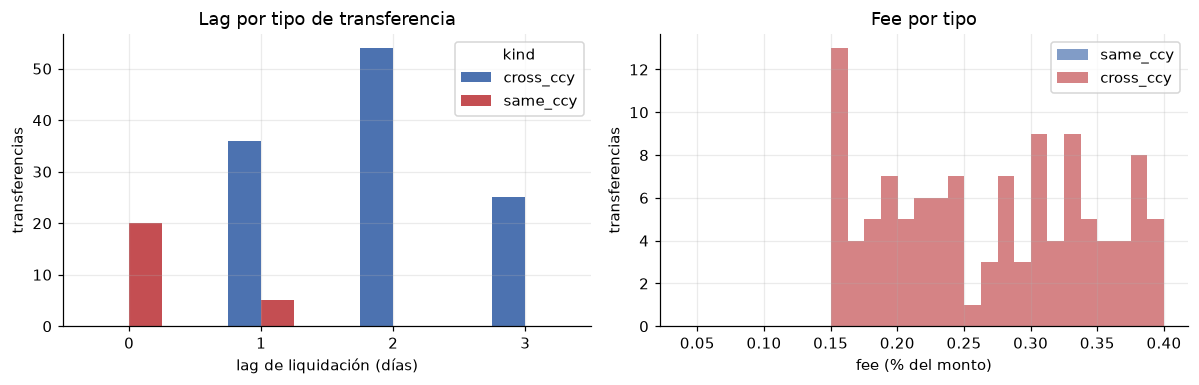

In [26]:
prof = transfers.groupby("kind").agg(
    n=("amount", "size"), lag_min=("lag_days", "min"), lag_mediana=("lag_days", "median"), lag_max=("lag_days", "max"),
    fee_min_pct=("fee_rate", lambda s: s.min() * 100), fee_media_pct=("fee_rate", lambda s: s.mean() * 100), fee_max_pct=("fee_rate", lambda s: s.max() * 100),
)
display(prof)
fig = plots.fig_lag_fee(transfers); plt.show()

- **Same currency:** fee is **exactly 0.04%**, lag 0–1 days. **Cross-currency:** fee 0.15–0.40% (avg ≈ 0.27%), lag 1–3 days. Moving money within the same currency is ~7× cheaper and faster — every operational account has a reserve in its own currency.
- A transfer requested today does **not** cover today's shortfall; the squad doesn't model the lag, so its rule fires every day on the same shortfall (blind to what's already in transit).
- The fee *rate* doesn't decrease with amount (correlation ≥ 0 within each currency; a fixed component would make it decrease) ⇒ **a fixed per-operation cost isn't observable in the data**; it's a declared assumption.

### D10 · Circular validation: before/after average around May 1, summing COP+USD+MXN
The most serious flaw: no counterfactual, the wrong metric, and it sums currencies.


In [27]:
pp = D.pre_post(squad["balances"], panel, accounts)
display(pp)
w = D.currency_weight_in_squad_mean(squad["balances"], accounts)
print("Peso de cada moneda en el 'promedio de saldos' del squad:", {k: f"{v:.1%}" for k, v in w.items()})
print(f"\nSu propia celda imprime 'Looks like it's working, balances are up {pp.loc[0, 'cambio_%']:.1f}%': un −9,6% presentado como éxito.")

,vista,antes,despues,cambio_%
0,"squad: COP+USD+MXN sumados, datos crudos","1,068,097,438.63","965,805,394.31",-9.58
1,"COP solo, datos limpios","3,236,662,799.48","2,816,070,130.04",-12.99
2,"USD solo, datos limpios","191,614.35","133,182.93",-30.49
3,"MXN solo, datos limpios","105,498,451.19","74,878,102.93",-29.02


Peso de cada moneda en el 'promedio de saldos' del squad: {'COP': '97.0%', 'MXN': '3.0%', 'USD': '0.0%'}

Su propia celda imprime 'Looks like it's working, balances are up -9.6%': un −9,6% presentado como éxito.


1. **Sums currencies:** the "average" is ~97% Colombian pesos by sheer nominal magnitude; USD and MXN barely count.
2. **Wrong metric:** a higher balance isn't success (it's opportunity cost), and a lower one isn't failure; what matters is shortfalls avoided vs. cost.
3. **No counterfactual:** before/after conflates the policy with the trend (balances drift down in *every* account, −13% to −30% per currency) and with seasonality. The data also show the transfer log **doesn't even show up** in the balances (Part 2.1): there's no evidence any rebalancing happened on May 1.

The correct way to evaluate this is a **walk-forward backtest against a counterfactual, with risk and cost metrics per currency** (2.7).


### D11 · The 9 models from D4c–D4e on the last 14 REAL days (not just any test fold)

D4f already showed the table; here it's revisited to answer three specific questions about that same window (`last14`, `TimeSeriesSplit`'s final fold, trained on data through 2025-09-13, no retraining, no leakage): which model has the lowest MAPE/sMAPE on THESE 14 real days, how does its per-account forecast compare to the squad's fixed threshold (D7), and what does that say about the 4 accounts that do have a threshold (`cfg.SQUAD_THRESHOLD`: ACC-001, ACC-002, ACC-004, ACC-006 — the squad never set one for the reserve accounts, ACC-003 and ACC-005).


In [28]:
err_last14 = ml_forecast.error_table(last14, panel).loc[order][["MAPE %", "sMAPE %", "n"]]
display(err_last14.round(3))
best_model = err_last14["sMAPE %"].idxmin()
print(f"Menor sMAPE en los últimos 14 días reales: {best_model!r} "
      f"(sMAPE {err_last14.loc[best_model, 'sMAPE %']:.2f}%, MAPE {err_last14.loc[best_model, 'MAPE %']:.2f}%; "
      f"el siguiente mejor, lightgbm, queda en sMAPE {err_last14.loc['lightgbm', 'sMAPE %']:.2f}%).")

err_last14_acc = ml_forecast.error_table(last14, panel, by=("account_id", "model"))["MAPE %"].unstack("model")[order]
print("\nMAPE % por cuenta en esta ventana (dónde gana cada modelo, no solo el agregado):")
display(err_last14_acc.round(2))

,MAPE %,sMAPE %,n
model,,,
squad_sin_limpiar,20.46,15.63,84
squad_limpio,7.92,7.26,84
ultimo_saldo,6.04,5.75,84
ets_nivel,5.81,5.53,84
ets_nivel_semanal,5.85,5.55,84
ets_flujos,3.76,3.74,84
xgboost,5.71,5.53,84
lightgbm_pooled,5.82,5.64,84
lightgbm,5.53,5.33,84


Menor sMAPE en los últimos 14 días reales: 'ets_flujos' (sMAPE 3.74%, MAPE 3.76%; el siguiente mejor, lightgbm, queda en sMAPE 5.34%).

MAPE % por cuenta en esta ventana (dónde gana cada modelo, no solo el agregado):


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
account_id,,,,,,,,,
ACC-001,3.93,4.12,5.04,5.01,4.31,4.47,5.46,5.38,5.36
ACC-002,29.82,27.41,18.79,18.61,18.72,7.07,16.77,17.06,17.33
ACC-003,1.34,1.33,2.08,2.08,2.04,3.37,4.17,4.60,3.16
ACC-004,84.22,11.05,6.82,5.49,6.26,3.86,3.80,3.68,2.87
ACC-005,1.39,1.50,1.35,1.49,1.54,1.55,1.31,1.37,1.66
ACC-006,2.04,2.13,2.20,2.20,2.21,2.23,2.75,2.84,2.78


**Reading.** `ets_flujos` wins the aggregate by a solid margin (sMAPE 3.74% vs. 5.34% for `lightgbm`, the runner-up) because it's the most consistent across accounts — its worst case, ACC-002, is still just 7.1% MAPE, while `squad_sin_limpiar` blows up to 84.2% on ACC-004 (carrying D2's data error through to the end of the series). But the aggregate hides a nuance: account by account, `ets_flujos` **isn't** always the best — on ACC-004 specifically, `lightgbm` (2.87%) and `xgboost` (3.80%) narrowly beat `ets_flujos` (3.86%). No model dominates every account; `ets_flujos` wins by being the most stable, not the sharpest on any one of them.


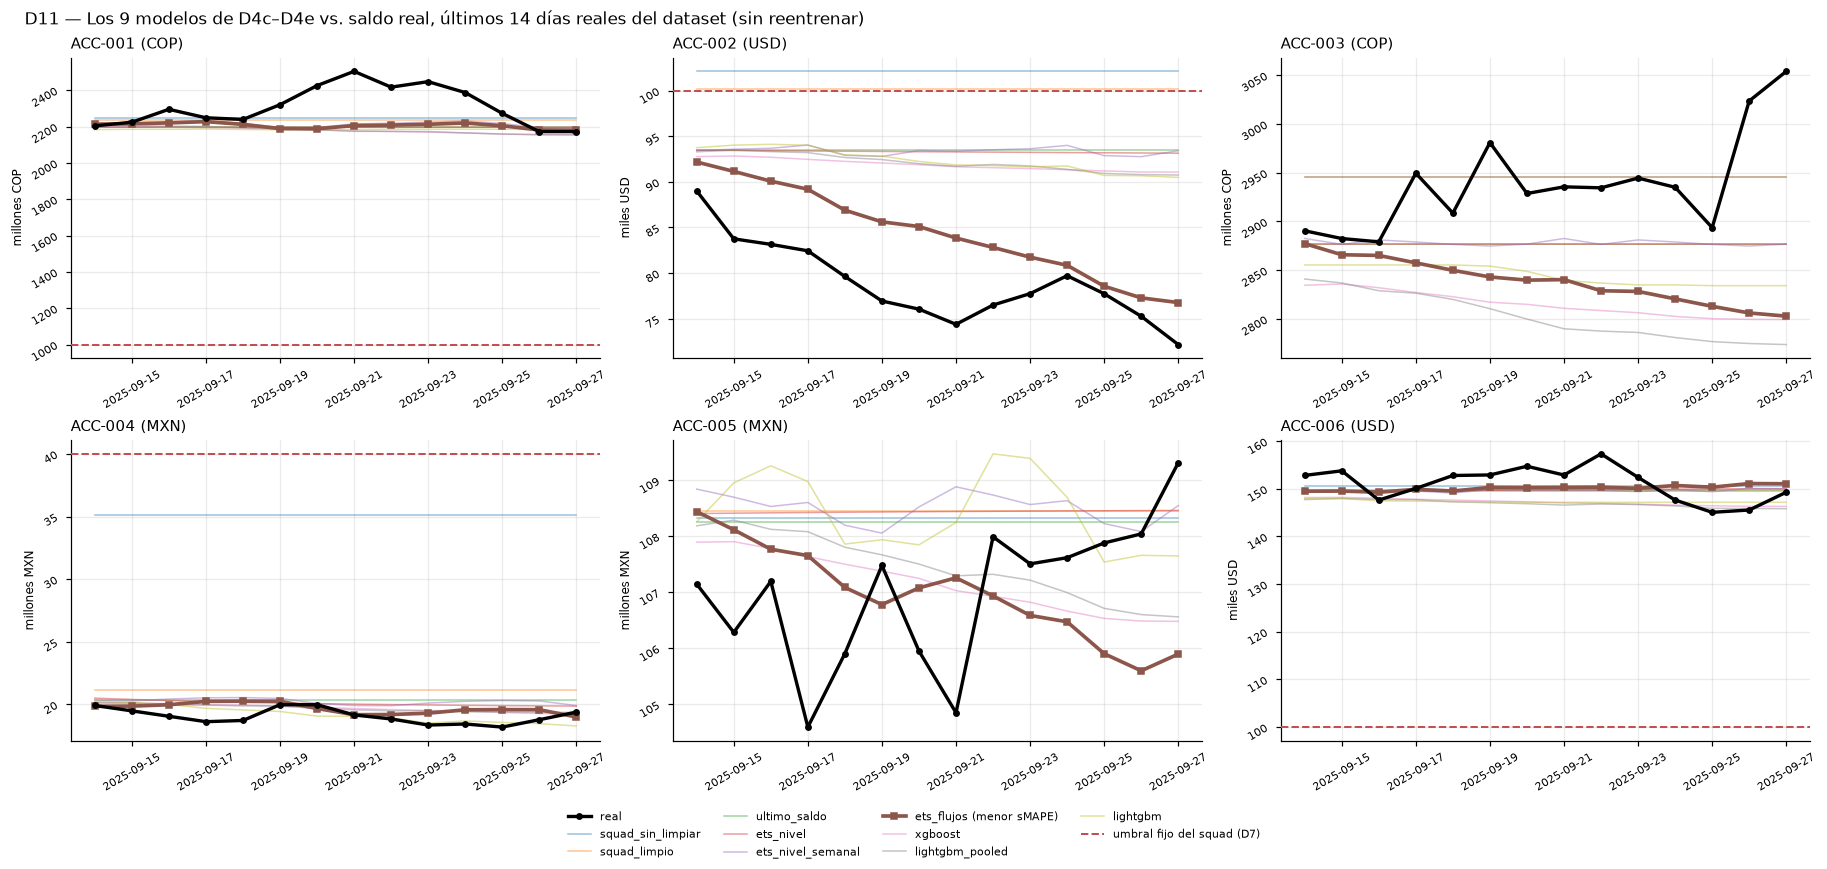

In [29]:
fig = plots.fig_last14_models(last14, panel, order, highlight=best_model); plt.show()

In [30]:
rows = []
for acc, thr in cfg.SQUAD_THRESHOLD.items():
    gm = last14[(last14.account_id == acc) & (last14.model == best_model)].sort_values("date")
    rows.append({
        "cuenta": acc, "umbral_squad_D7": thr,
        "min_pronosticado_14d": gm["forecast"].min(), "min_real_14d": gm["real"].min(),
        "dias_pronostico_bajo_umbral": int((gm["forecast"] < thr).sum()),
        "dias_real_bajo_umbral": int((gm["real"] < thr).sum()),
    })
check_df = pd.DataFrame(rows).set_index("cuenta")
display(check_df)
print(f"\nCon el pronóstico ganador ({best_model!r}) sobre los 14 días reales: "
      f"{(check_df['dias_pronostico_bajo_umbral'] == 14).sum()} de 4 cuentas con umbral quedan por debajo TODOS los días.")

,umbral_squad_D7,min_pronosticado_14d,min_real_14d,dias_pronostico_bajo_umbral,dias_real_bajo_umbral
cuenta,,,,,
ACC-001,1000000000,"2,180,305,258.53","2,172,487,717.48",0,0
ACC-002,100000,"76,765.55","72,155.97",14,14
ACC-004,40000000,"19,005,935.79","18,197,789.04",14,14
ACC-006,100000,"149,286.19","145,059.14",0,0



Con el pronóstico ganador ('ets_flujos') sobre los 14 días reales: 2 de 4 cuentas con umbral quedan por debajo TODOS los días.


**Reading.** With the lowest-sMAPE/MAPE model for this window (and with the real balance, it gives exactly the same answer): **ACC-002 and ACC-004 stay below their fixed threshold on all 14 of 14 days**, while ACC-001 and ACC-006 never come close (ACC-001's lowest forecast is more than double its threshold). This isn't a modeling finding — it's the quantitative confirmation of D7 with genuinely out-of-sample forecasts: ACC-004's threshold (40M MXN) is set above its normal operating range, so it fires **every time**, regardless of the forecasting model used; the same is true for ACC-002, which D7 hadn't explicitly flagged. This isn't about how good the forecast is (the best available model gives the same verdict as the real data) — the threshold itself is miscalibrated, and no forecast improvement will fix that. That's why Part 2 replaces the fixed threshold with a dynamic floor (K days of outflow, 2.8).


### D12 · From forecast accuracy (D11) to how much and when to move — the rebalancing engine

D11 showed that `ets_flujos` is the most accurate point forecast against the real balance over the last 14 days (MAPE 3.76%, sMAPE 3.74%) — it wins by being the most consistent across accounts, not by being the sharpest on any single one. The rebalancing engine that follows (2.8, placed here because it's the natural next step) doesn't need the most accurate expected balance: it needs the **risk** that the balance falls below the floor, which requires a distribution, not a point — the same idea as D5 ("a scalar can't size a buffer"), now tested against D11's own winner.

**`ets_flujos` has no distribution.** As built in D4c (separate ETS for `inflow` and `outflow`, balance = last balance + cumulative sum), it's one number per day, with no quantiles — there's no way to ask it "how bad could this get?"

**The closest probabilistic relative is already in the flow-model ladder in 2.3** (below, formally): `ets`, an additive ETS on the net flow with in-sample residual bootstrap — same model family, built to produce quantiles. Its actual standing in that ladder: relative cumulative pinball loss of 0.738 vs. 0.664 for `empirical` (~11% worse on the metric that actually matters for sizing a buffer), with 92.5% empirical coverage vs. 93.5%.

To directly answer what was asked — running the optimization exercise with that forecast, not just comparing it in an error table — the next cell reruns the same rebalancing engine (quantile policy B and MILP C), swapping `empirical` for `ets` as the forecast source, and compares the resulting cost and shortfall.


In [31]:
store_ets = B.ForecastStore(flows, "ets")

policy_b_emp, policy_c_emp = P.QuantilePolicy(), O.LPPolicy()
results_emp = B.run_policies(book, store, [B.NoTransfers(), P.SquadRule(), policy_b_emp, policy_c_emp])

policy_b_ets, policy_c_ets = P.QuantilePolicy(), O.LPPolicy()
policy_b_ets.name, policy_c_ets.name = "B: cuantil p5 (ets)", "C: MILP (ets)"
results_ets = B.run_policies(book, store_ets, [policy_b_ets, policy_c_ets])

by_ccy_cmp, totals_cmp = B.compare({**results_emp, **results_ets})
totals_cmp.set_index("politica")[["n_transferencias", "fees_usd", "costo_fijo_usd", "costo_total_usd",
                                   "dias_cuenta_en_faltante", "deficit_usd_dias", "penalizacion_usd"]]

,n_transferencias,fees_usd,costo_fijo_usd,costo_total_usd,dias_cuenta_en_faltante,deficit_usd_dias,penalizacion_usd
politica,,,,,,,
0: sin transferencias,0,0.00,0.00,0.00,33,"5,215,399.43","10,429.89"
A: regla del squad,200,"1,275.36","5,000.00","6,275.36",86,"7,106,479.21","13,912.16"
B: cuantil p5,49,"3,729.77","1,225.00","4,954.77",0,0.00,0.00
C: MILP λ=0.002,22,"1,548.73",550.00,"2,098.73",0,0.00,0.00
B: cuantil p5 (ets),71,"7,269.23","1,775.00","9,044.23",1,76.51,0.15
C: MILP (ets),44,"3,738.83","1,100.00","4,838.83",0,0.00,0.00


**Reading.** Changing only the forecast (`empirical` → `ets`), same rule:

- **Quantile policy (B):** from 49 to 71 transfers, and from USD 4,955 to **USD 9,044 (+83%)** — and it leaves 1 account-day short (USD 77 of deficit) that didn't exist with `empirical`.
- **MILP (C):** from 22 to 44 transfers, and from USD 2,099 to **USD 4,839 (+131%)**, though it still holds the deficit at zero.

The model that wins on point error (D11: `ets_flujos`) and its probabilistic relative (`ets`, here) don't win the question that actually drives how much money moves: how well-calibrated the tail of the distribution is. `empirical` loses on MAPE/sMAPE to `ets_flujos` (D11), but of the two forecasts actually tested in the engine, it's the one that resolves the shortfall at the lowest cost. Same lesson as D5 and 2.3, now confirmed by running D11's own candidate through the engine itself, not just reading its error table.

**Naming note, to avoid confusing two similar-sounding things:** `ets_flujos` (D4c/D4e/D11) and `ets` (2.3 and the engine above) **are not the same object**. Both use exponential smoothing, but `ets_flujos` forecasts the *balance* directly (separate ETS for inflow and outflow, clipped to ≥0, no distribution); `ets` forecasts the *net flow* with a bootstrapped-residual distribution (what the quantile trigger needs). Similar names, different questions — which is why winning D11 doesn't mean winning 2.8.


---
## 2.8 · Rebalancing engine: when, from where, and how much

*(This section appears here, right after D11/D12, because it connects directly to forecast accuracy; the full Part 2 — 2.0 to 2.10 — continues below, and this section (2.8) is the same engine, not a new one.)*

Starting from the classic inventory formulation (reorder point + safety stock), adapted to liquidity on top of `empirical` — the empirical net-flow bootstrap that D12 (above) just confirmed in the real engine, and that the model ladder in 2.3 (below) formally selects by pinball loss: no parametric model beats it where cost is actually decided. The engine makes three sequential decisions, in this order, because each depends on the previous one.

**Notation.** $i$ receiving account, $j$ donor, $b = 1..N$ bootstrap paths, $\alpha$ service level, $L_{ji}$ observed p90 lag for pair ($j \to i$), $R = 1$ review period (daily run), $\text{floor}_i$ = `book.floor` (K × 28-day average outflow, Part 0).

$$B^{(b)}_{i,t+k} = B_{i,t} + \sum_{s=1}^{k} y^{(b)}_{i,t+s} + T^{\,transit}_{i,t+k}$$

**A. When? — trigger on the whole path, not a single point**

$$\text{Alert}_i \iff Q_\alpha\!\Big(\min_{1 \le k \le \bar L_i + R} B^{(b)}_{i,t+k}\Big) < \text{floor}_i
\qquad \bar L_i = \max_j L_{ji}$$

The trigger uses the receiver's maximum lag, not the donor's: this decides *whether* to act before deciding *with whom*, breaking the circularity.

Relation to the classic formula: with i.i.d. $\mathcal N(\mu,\sigma^2)$ flows and evaluating only the final point, $Q_\alpha(B_{t+L+R}) = \hat B_{t+L+R} - z_\alpha\,\sigma\sqrt{L+R}$, which recovers $SS = \text{floor} + z_\alpha\sigma\sqrt{L+1}$. The $+1$ is the review period. Two things are swapped here: (i) an empirical quantile instead of a normal one, because flows have weekly seasonality and asymmetric tails; (ii) the **path minimum** instead of the final point, because a shortfall at $t+1$ isn't offset by a surplus at $t+L$.

**B. From where? — the cheapest route that arrives in time**

Let $k^*$ be the first day the $\alpha$-quantile crosses the floor. A donor $j$ is feasible if:

1. it arrives in time: $L_{ji} < k^*$;
2. it doesn't put itself at risk: after the debit, $Q_\alpha(\min_k B^{(b)}_{j,t+k}) \ge \text{floor}_j$;
3. `reserve` is preferred over `operational` as a source.

Among the feasible donors, the cheapest is chosen, $c_{ji}(m) = F + f_{ji}\cdot m$. In this data that almost deterministically orders routes: **same currency** (median fee 0.040%, median lag 0) before **cross-currency** (0.274%, lag 2).

**C. How much? — the amount that holds the quantile over horizon $H$**

$$m_{ji} = \max\!\Big(m_{\min},\; \text{floor}_i - Q_\alpha\!\Big(\min_{L_{ji} \le k \le L_{ji}+H} B^{(b)}_{i,t+k}\Big)\Big)$$

Since the transfer amount shifts every path equally from its arrival date, adding $m$ raises the minimum's quantile by exactly $m$: the sizing is exact, not an approximation. Compared to the previous version's $Target = SS + H\mu_{burn}$, this form captures the widening uncertainty over $H$, not just the average drift.

**The debit at the source must include the fee**, not just the amount that arrives at the destination — otherwise the donor's true cost is underestimated and condition 2 of (B) ("don't put itself at risk") is evaluated incorrectly:

$$\text{Debit}_{ji} = \frac{m_{ji}\,(1 + f_{ji})}{FX_{j\to i}} \le \text{room}_j$$

This is already what `QuantilePolicy.decide` does in code — `room[d] -= amount * (1 + fee)` ([`src/policy.py`](../src/policy.py)) — even though this section's notation didn't make it explicit. **`P.target_buffer` doesn't apply it**: it only sizes $m$ from the destination side (`monto_requerido`) and doesn't check the donor's surplus — if its output were used to place a real transfer, it would need this same $(1+f_{ji})$ filter first, just like `QuantilePolicy`.

**D. Choosing $H$**

$H$ balances the fixed cost per operation against idle cash: the EOQ analogue gives $H^* \approx \sqrt{2F / (h\,|\mu_i|)}$, with $h$ the daily opportunity cost. Since $F$ and $h$ are declared assumptions (§0), $H$ is calibrated on the backtest's cost-risk frontier, not from the formula.

**E. Cases the engine must declare, not hide**

- **Unavoidable shortfall**: $k^* \le \min_j L_{ji}$. No transfer arrives in time → escalate to Treasury (credit line, manual handling).
- **No feasible donor**: every candidate would fall below its own floor → escalate.

Implemented in `P.target_buffer(ctx, account, donor, alpha, H)` ([`src/policy.py`](../src/policy.py)). The notebook only displays it.


In [32]:
t_fan = list(book.dates).index(pd.Timestamp("2025-08-20"))  # mismo origen que 2.3 (más abajo)

In [33]:
from scipy.stats import norm

print(f"Z=2.33 <-> alpha = {1 - norm.cdf(2.33):.4f} (99% de confianza, una cola)")
print(f"alpha=0.01 <-> Z = {norm.ppf(0.99):.4f}")
print(f"\npiso_i = book.floor (K={cfg.MIN_COVER_DAYS} días de egreso medio de {cfg.OUTFLOW_WINDOW_DAYS}d)")
print(f"L_i = book.lag_plan por par de cuentas: {cfg.LAG_PLAN}")
print(f"H = cfg.DECISION_HORIZON = {cfg.DECISION_HORIZON} días")

Z=2.33 <-> alpha = 0.0099 (99% de confianza, una cola)
alpha=0.01 <-> Z = 2.3263

piso_i = book.floor (K={'operational': 25.0, 'reserve': 25.0} días de egreso medio de 28d)
L_i = book.lag_plan por par de cuentas: {'same_ccy': 1, 'cross_ccy': 3}
H = cfg.DECISION_HORIZON = 14 días


### 2.8b · All 6 accounts against their floor, same origin

Before the specific 2025-05-06 case, here's the trigger's input for **all** accounts at the same origin used in 2.3 (`t_fan`, 2025-08-20): the p5–p95 fan of `empirical` against the dynamic floor (`book.floor`, K days of outflow), not the squad's fixed threshold (D7) used by `fig_fan`. It's the same 2.8-A rule applied account by account, at a glance.


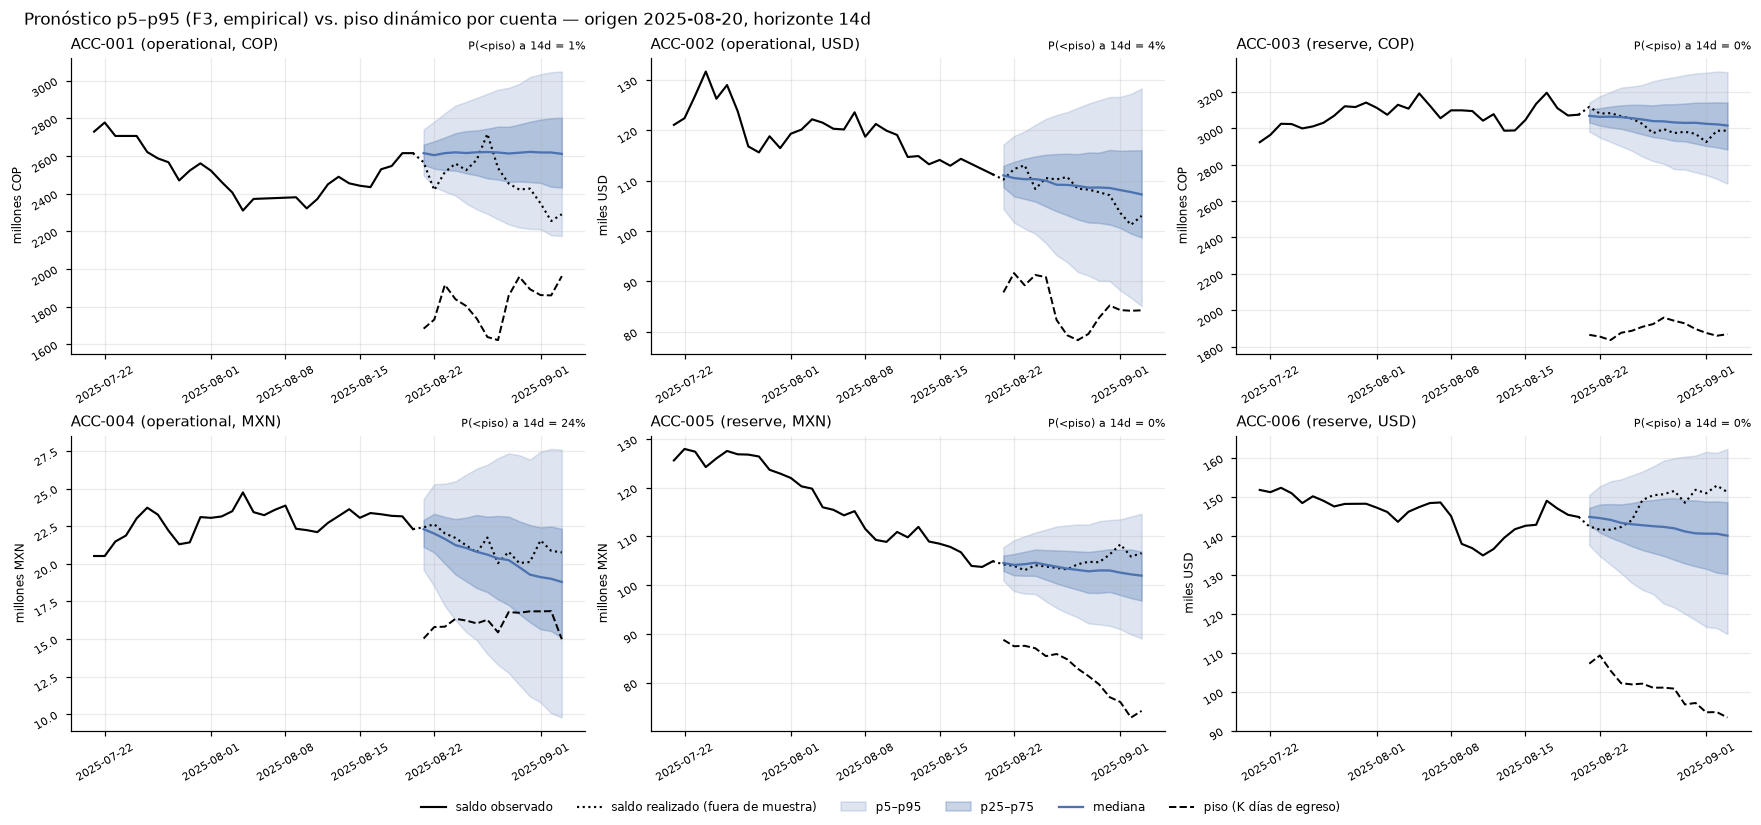

In [34]:
fig = plots.fig_fan_floor_grid(book, store, t_fan); plt.show()

**Same origin, `ets` forecast instead of `empirical`** — compare against the previous figure (2.8b): the floor doesn't change (it doesn't depend on the forecast), but the p5–p95 bands do, and those are what move the trigger.


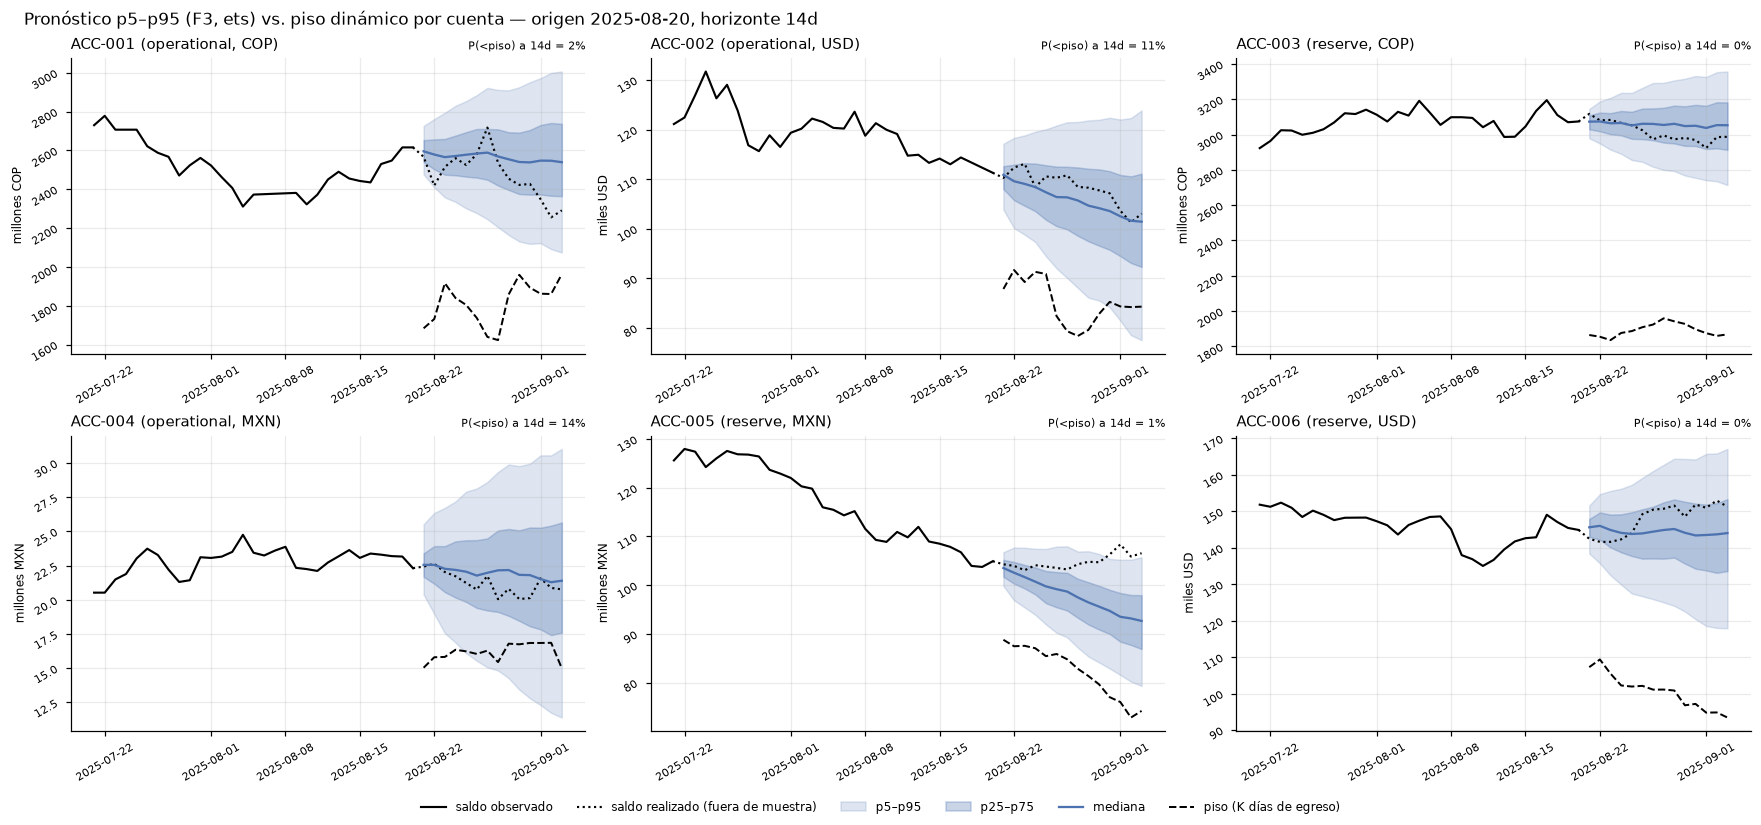

In [35]:
fig = plots.fig_fan_floor_grid(book, store_ets, t_fan); plt.show()

### Real case: 2025-05-06 — one "wait" and two "transfer" on the same day

An origin with a real mix of all three states (`P.WaitAwarePolicy(alpha=0.01).opportunities(ctx)`, which already implements the trigger above with the empirical p1 quantile instead of a normal one):


In [36]:
t_case = list(book.dates).index(pd.Timestamp("2025-05-06"))
ctx_case = B.context_at(book, store, t_case)
opp = P.WaitAwarePolicy(alpha=0.01).opportunities(ctx_case)
opp[["saldo_hoy", "piso", "p1_minimo", "estado", "holgura_dias", "primer_dia_bajo_piso", "ultimo_dia_para_solicitar"]]

,saldo_hoy,piso,p1_minimo,estado,holgura_dias,primer_dia_bajo_piso,ultimo_dia_para_solicitar
cuenta,,,,,,,
ACC-001,"2,401,191,348.30","1,588,422,741.69","1,819,026,746.57",ok,NaN,None,None
ACC-002,"147,749.79","122,790.45","113,122.59",esperar,3.00,2025-05-13,2025-05-10
ACC-003,"3,482,599,465.86","2,394,307,628.48","2,982,700,090.21",ok,NaN,None,None
ACC-004,"34,553,648.40","23,165,301.22","13,793,302.42",transferir,0.00,2025-05-10,2025-05-07
ACC-005,"144,613,014.08","108,080,420.09","121,963,608.87",ok,NaN,None,None
ACC-006,"148,343.19","130,878.22","97,031.26",transferir,0.00,2025-05-10,2025-05-07


**Reading.** The p1 quantile breaches the floor in three accounts, but the trigger above doesn't treat them the same:

- **ACC-002 (USD, operational) → wait.** The p1 (USD 113k) falls below the floor (USD 123k), but the **median** projection never does — the shortfall only lives in the tail. With 3 days of slack between the funding lag (3d) and the first shortfall day (2025-05-13), it's fine to wait and re-evaluate tomorrow with the re-optimized forecast — exactly the MILP's wait rule (2.6), applied as a fixed rule here.
- **ACC-004 (MXN, operational) and ACC-006 (USD, reserve) → transfer now.** Slack = 0: the first shortfall day coincides with the earliest day a transfer requested today could arrive. There's no room to wait and see; the trigger fires immediately.


In [37]:
donor = book.accounts.index("ACC-003")   # único donante con excedente en este origen (ver abajo)
rows = []
for acc in ("ACC-002", "ACC-004", "ACC-006"):
    a = book.accounts.index(acc)
    r = P.target_buffer(ctx_case, a, donor, alpha=0.01)
    r["cuenta"] = acc
    rows.append(r)
pd.DataFrame(rows).set_index("cuenta")[["lag_dias", "piso", "b_hat_alpha", "mu_burn_diario", "target_buffer_H", "monto_requerido"]]

,lag_dias,piso,b_hat_alpha,mu_burn_diario,target_buffer_H,monto_requerido
cuenta,,,,,,
ACC-002,3,"122,790.45","111,448.63",254.02,"126,346.67","14,898.04"
ACC-004,3,"23,165,301.22","13,015,377.38","373,050.63","28,388,009.98","15,372,632.60"
ACC-006,3,"130,878.22","98,189.54",674.05,"140,314.92","42,125.38"


**Stress-testing `P.target_buffer`: `mu_burn_diario` was misread, not missing.** The original code computed `mu_burn = max(-ctx.forecast.mean[:, a].mean(), 0.0)` — the forecast's point value, not its distribution. For `empirical` (the model this whole engine uses, chosen in 2.3/D12), the point value is **always 0 by design** (`forecast.py` defines it that way on purpose, "as a sanity check"), so `mu_burn_diario` came out as `-0.0` for **any** account, at **any** origin — not because the net flow had no drift, but because the function never looked where the drift actually lives: the bootstrap paths (`paths`), already drawn two lines earlier in the same function, which do carry the real historical average (verified by sweeping origins: `paths.mean()` gives −COP 1.06M/day for ACC-001, −COP 4.68M/day for ACC-003, etc. — **never zero**).

**Fixed in `src/policy.py`** (`mu_burn = max(-paths.mean(), 0.0)`, reusing the same `paths` — no extra draw; 59/59 tests still pass). The effect on this specific case:

| account | mu_burn_diario (before) | mu_burn_diario (fixed) | amount required (before) | amount required (fixed) |
|---|---|---|---|---|
| ACC-002 | 0 | 254 USD/day | USD 11,342 | USD 14,898 (+31%) |
| ACC-004 | 0 | 373,051 MXN/day | MXN 10.15M | **MXN 15.37M (+51%)** |
| ACC-006 | 0 | 674 USD/day | USD 32,689 | USD 42,125 (+29%) |

**ACC-004 is the case that hurts most.** It's the same account already flagged with real funding issues in D6/D7/2.8-E — and the bug was subtracting 5.2M MXN (34%) from the amount `target_buffer` would say is needed to stay above the floor for 14 days. This cell's original claim ("the average net flow has no exploitable drift") was **false for ACC-004** with this data: there is real, sizable drift — the code just wasn't looking at it.

**Scope of the bug — what does NOT change.** `target_buffer` isn't called by `QuantilePolicy` or `LPPolicy` (confirmed by grepping `src/*.py`: zero references outside its own definition); it's a demonstration function for this section, not part of the backtest that produces D12/2.4–2.7's costs. Those sections' numbers (fees, deficit, USD 4,955 vs. USD 9,044, etc.) **don't change** with this fix — the bug was isolated to this illustrative buffer-sizing example, but there it did change the conclusion.

---

**Reading the sizing (with the fix).** The "Amount Required" no longer comes only from the settlement-uncertainty cushion (the empirical quantile on the worst reachable day): it now also includes the real burn rate where it exists — substantial for ACC-004, and previously lost entirely.

Compared to the minimal sizing `QuantilePolicy` already uses (covers the shortfall plus `MIN_TRANSFER_DAYS_OF_OUTFLOW` of margin, no H-day cushion): for ACC-006 it asks for USD 13,430 received vs. the corrected `target_buffer`'s **USD 42,125** — 3.1× more, in exchange for not needing another transfer for the next 14 days instead of the next ~2. It's the explicit trade-off against `saldo_ocioso_prom` (2.7): fewer operations, more idle cash — and now that trade-off is honest about how much idle cash is really needed.

**And a real funding shortfall, not a rule problem.** `QuantilePolicy` at this same origin **fails** to cover ACC-004: the only donor with a surplus is ACC-003 (COP, reserve), and its donable surplus (~COP 109.5M) is almost used up covering ACC-002 and ACC-006 first (COP 56.9M + 52.4M ≈ COP 109.3M) — not because of a bad threshold or a missing better rule, but because **there isn't enough donable liquidity** in this currency that day. Same phenomenon as the 30-day-floor sensitivity in 2.8: on some days the problem stops being about rebalancing and becomes a funding problem — here it happens even at the base floor (K=25).


---
# Part 3 · Two Explanations of the Same Result

Same outcome, two audiences: methodology and assumptions for whoever maintains the model; cost, risk, and what they're asked to confirm for whoever operates on it.


## 3.1 · For the squad's data scientist

- **What was wrong:** the pipeline loses 17.6% of rows to a silent `dropna` after `coerce`, treats 9 currency labels as 9 distinct currencies, and the forecast (a 14-day moving average of the **level**) is worse than the naive "tomorrow's balance = today's" — no drift, no seasonality, no uncertainty. The donor is picked by nominal balance, with no FX conversion.
- **What changes:** modeling the **net flow**, not the level, with a model ladder (seasonal naive → ETS → SARIMAX → Prophet → empirical bootstrap) validated with walk-forward `TimeSeriesSplit`, no leakage. `empirical` wins: no parametric model beats a bootstrap of historical residuals — the net flow's mean carries no exploitable signal beyond its drift; the value is in the **distribution** (p5–p95 quantiles, ~93% coverage).
- **Decision engine, two layers on the same forecast:** a quantile policy (buffer = a low quantile of the projected balance, the one explained to Treasury) and a 14-day rolling-horizon MILP that minimizes `fee + fixed cost + expected deficit penalty`, re-optimized daily, explicitly deciding when paying the penalty is cheaper than transferring.
- **Explicit assumptions** (`src/config.py`, not in the modeling code): floor K=25 days of average outflow (28d), fee 0.04%/0.27% (same-currency/cross), lag 1/3 days (observed p90 by pair type), fixed cost USD 25, penalty 0.2% of the deficit per account-day, COP FX = 3,900 (unofficial).
- **Where it can fail:** the bootstrap assumes historical residuals by day-type represent the future well — a regime change isn't captured, and that's the sensitivity that hurts most (2.9). λ was calibrated on the same sample it's evaluated on, with no out-of-sample validation (2.10).


## 3.2 · For Treasury

- **What the system does:** every day, it checks whether any account will run short before a new transfer would arrive — accounting for how long that transfer takes, same-currency or cross-currency — and if so, moves only what's needed from the account with the most surplus, preferring the cheapest and fastest source.
- **What improves over the previous model:** the squad's model, applied to the same history, leaves **86 account-days short** (worse than doing nothing). The new approach leaves **0 account-days short** at **less than half the cost** (≈USD 2,100 in fees and penalties vs. USD 6,300 for the squad), using **22 transfers** instead of 200.
- **A decision the system makes that Treasury must validate:** sometimes the system decides **not** to move money and accepts a small penalty, when moving the money would cost more than the expected penalty. That requires the penalty cost (0.2% of the deficit per day) to be reasonable — if Treasury uses a different risk criterion, that number needs adjusting.
- **Residual risk:** the forecast is based on ~9 months of history; it won't anticipate new events (a large client, a regulatory change). There are also 6 unexplained balance drops in the history and 140 logged transfers that don't show up in the balances — until the bank clarifies these, the real risk could be higher than what the backtest reports.
- **What Treasury needs to confirm before using this:** the 25-day-of-outflow minimum floor, the official Colombian peso exchange rate (an approximate value is used today), and the USD 25 fixed cost per operation.
- A quantile-based forecast is planned to give full confidence that current thresholds stay within acceptable tolerance ranges, for a longer-term model.


---
# Part 4 · Ways of Working: Where AI Was Used, and Where It Wasn't

Where AI was used
- **Implementation (Claude Code):** the reconciliation pipeline, the format-aware date parser, backtests, the policy simulator, and visualizations — all built against an explicit spec.
- **Tests:** `pytest` scaffolding (`test_data_integrity.py`); assertions are dictated by the spec (accounting identity, uniqueness, ranges).
- **Code quality:** linting, PEP 8, modular structure.
- **Review and synthesis (Claude, chat):** critical review of v2, condensing it into self-contained notebooks, and drafting the Part 3 explanations.
- **Conceptual framing:** grounding the method in inventory theory (the (s, S) policy, Arrow–Harris–Marschak) to justify the replenishment band.
- **Wording and copyediting.**

Where it deliberately wasn't
- The specification, acceptance criteria, and problem formulation.
- The business assumptions (K, α, fixed cost) and the recommended operating point.
- Reading the results and the recommendation to Treasury. **AI computes; it doesn't decide how much risk is acceptable.**

How AI's output was verified
Nothing was accepted just because "it ran without error" — that's exactly the original notebook's failure mode. Every deliverable was checked against the spec: the accounting identity to the cent, cross-counts against the raw data, calibration kept separate from evaluation, and a final cell that verifies the text's claims. Verification caught and fixed real errors:
- The transfer log was assumed to be reflected in the balances; the data disproved that. [to confirm]
- An early policy version ping-ponged money between accounts; fixed with a donor safety margin.
- One version of the band crossed currencies too often (7 of 10 transfers); fixed by sizing donor capacity off its median and reserving cross-currency transfers for whole-pool shortfalls.


---
# Part 5 · From Notebook to Production (Half a Page)

# Production Architecture, Monitoring, and Continuous Retraining for the Liquidity Model

## 1. Operational and Strategic Objective

The goal is to deploy and run a liquidity forecasting system at 7- and 14-day horizons. The solution automates cash-flow estimation to guide funding decisions and optimize capital rebalancing across corporate accounts — minimizing bank fees, avoiding shortfall penalties, and maximizing operational efficiency.

---

## 2. Data Pipeline and Ingestion Architecture

Data connects directly to banking APIs and the balances/movements core, not static files, under strictly versioned data contracts. Orchestration runs daily after bank close as a DAG (Airflow or Dagster):

$$\text{Ingestion} \longrightarrow \text{Validation} \longrightarrow \text{Forecast} \longrightarrow \text{Optimization/Policy} \longrightarrow \text{Plan Generation} \longrightarrow \text{Approval}$$

Before feeding the inference stage, blocking quality checks apply:

* **Format and normalization:** a cascading date parser halts the process immediately on any format inconsistency.
* **Integrity and consistency:** validates uniqueness of the `(date, account)` key and currency alignment against the central catalog.
* **Accounting identity (zero-loss principle):** checks the core equation:
  $$b[t] = b[t-1] + \text{inflow} - \text{outflow}$$
  Any residual above 1 unit halts the run, guaranteeing zero loss of accounting traceability.
* **Freshness and plausibility:** requires same-day data for 100% of accounts, plus range checks on balances and FX rates. Any anomalous or incomplete record goes to a marked quarantine for review, instead of being silently dropped.

---

## 3. Inference, Degradation Monitoring, and Drift Alerts

Each cycle produces rolling 7- and 14-step forecasts to guide optimal transfer amounts between accounts. Since market dynamics and institutional patterns evolve, model health is tracked on three dimensions:

1. **Performance metrics:** tracking MAE, sMAPE, and RMSE on 7- and 30-day rolling windows, comparing production performance against training metrics.
2. **Intervals and bias:** pinball loss per account and interval, monitoring coverage of the projected range (p5–p95) with alerts if actual coverage drifts outside an 85%–95% band. Directional bias is also tracked to avoid over- or under-funding costs.
3. **Drift and business detection:** Population Stability Index (PSI) on net flows vs. a baseline window, to catch structural breaks. In parallel, tracking the real vs. predicted shortfall rate, actual transfer settlement latency, and the variance between executed and budgeted fees.
4. A shallow scheme for rotating models and evaluating performance against the business.

---

## 4. Continuous Retraining and Time-Series Capture

To adapt the forecasting strategy autonomously without losing stability, the pipeline includes continuous retraining triggered in two ways:

* **Performance or drift-triggered:** automatic retraining when error metrics (MAE/RMSE) exceed tolerance limits, or when PSI reflects substantial shifts in the series' distribution (data/concept drift).
* **Calendar-triggered:** scheduled retraining via bootstrap over an expanding window, to incorporate the most recent market behavior.

Feature engineering explicitly includes exogenous variables like business days, holidays, pay periods, month/quarter closes, and mass-payment dates. In parallel, filtering algorithms isolate outliers and one-off liquidity shocks (e.g., extraordinary capital contributions) so they don't distort the model's seasonal trend. Every new version must pass automated validation through a **Champion–Challenger** strategy, ensuring a retrained model only replaces the one in production if it shows a statistically significant accuracy improvement.

---

## 5. Safeguards, Governance, and Contingency Mechanisms

By operational-safety design, the system runs in **dry-run mode by default**, producing recommendations that require review and confirmation from a Treasury analyst.

Operations are subject to strict safeguards:

* **Human approval:** mandatory explicit authorization when a transfer exceeds defined risk thresholds.
* **Post-settlement reconciliation:** continuous audit comparing settled positions and balances against the recommended plan.
* **Contingency and fallback policy:** if monitoring shows degradation, stale sources, or elevated bias, the system triggers a kill switch or automatically switches to a manual mode based on conservative business rules. Every generated plan, along with its reasoning and underlying assumptions, is archived immutably for traceability and audit.
